In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
path= 'orders_data_market_basket_analysis.csv'
data= pd.read_csv(path)
df= data.copy()

In [3]:
df.head()

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
0,CA-2017-152156,11/8/2017,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2017-152156,11/8/2017,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2017-138688,6/12/2017,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2016-108966,10/11/2016,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2016-108966,10/11/2016,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
len(df['Order ID'].unique())

5009

In [5]:
c= df.groupby('Order ID')['Product Subcategory'].apply(list)

In [6]:
te= TransactionEncoder()
basket= te.fit_transform(c)
basket= pd.DataFrame(basket, columns= te.columns_)

In [7]:
basket

,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5004,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
5005,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5006,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5007,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [8]:
fi= apriori(basket, min_support=.01, use_colnames= True)
fi

,support,itemsets
0,0.143342,(Accessories)
1,0.090038,(Appliances)
2,0.145937,(Art)
3,0.262727,(Binders)
4,0.044720,(Bookcases)
...,...,...
63,0.023358,"(Phones, Storage)"
64,0.010381,"(Phones, Tables)"
65,0.010182,"(Binders, Furnishings, Paper)"
66,0.010781,"(Phones, Binders, Paper)"


In [9]:
fi.sort_values('support', ascending= False)
# binders appears in 26% of all transactions
# paper appears in 23% of all transactions

,support,itemsets
3,0.262727,(Binders)
12,0.237772,(Paper)
9,0.175085,(Furnishings)
13,0.162507,(Phones)
14,0.155121,(Storage)
...,...,...
62,0.010781,"(Tables, Paper)"
66,0.010781,"(Phones, Binders, Paper)"
67,0.010581,"(Storage, Binders, Paper)"
64,0.010381,"(Phones, Tables)"


In [10]:
fi['itemsets']= fi['itemsets'].apply(lambda x: x if len(x)== 2 else None)

In [11]:
fi= fi.dropna()

In [12]:
top_pairs= fi.sort_values('support', ascending= False)
# binders > papers frequently bought together 5% of all transactions
# binders, phones 3.9%
top_pairs.head()

,support,itemsets
43,0.054901,"(Binders, Paper)"
44,0.039728,"(Phones, Binders)"
45,0.039728,"(Storage, Binders)"
41,0.039529,"(Binders, Furnishings)"
61,0.035536,"(Storage, Paper)"


In [13]:
top_pairs['item1'] = top_pairs['itemsets'].apply(lambda x: list(x)[0])
top_pairs['item2'] = top_pairs['itemsets'].apply(lambda x: list(x)[1])

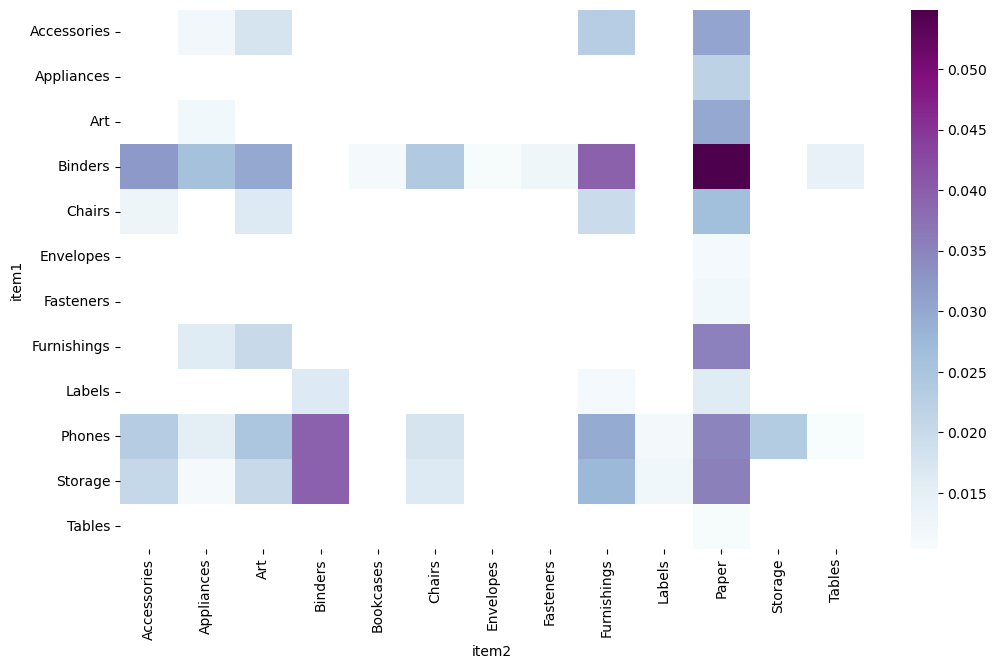

In [14]:
heatmap= pd.crosstab(top_pairs['item1'], top_pairs['item2'], values= top_pairs['support'], aggfunc= 'mean',
                     dropna= True)
plt.figure(figsize= (12 ,7))
sns.heatmap(heatmap, cmap= 'BuPu')
plt.show()

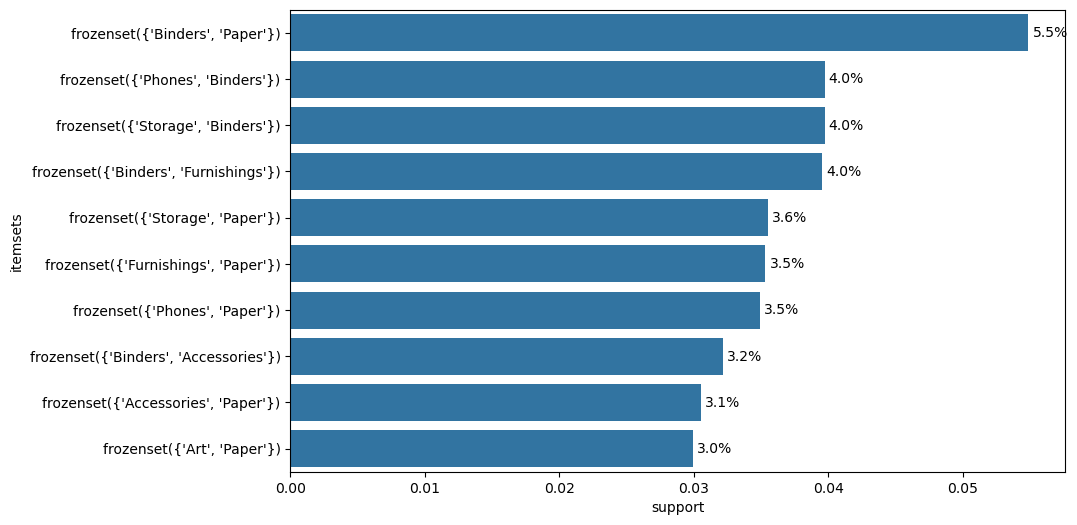

In [15]:
# Sorting and selecting top 10
fi_top10 = fi.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [16]:
fi3= apriori(basket, min_support=.01, use_colnames= True)
fi3['itemsets']= fi3['itemsets'].apply(lambda x: x if len(x)== 3 else None)
fi3= fi3.dropna()
fi3.head()

,support,itemsets
65,0.010182,"(Binders, Furnishings, Paper)"
66,0.010781,"(Phones, Binders, Paper)"
67,0.010581,"(Storage, Binders, Paper)"


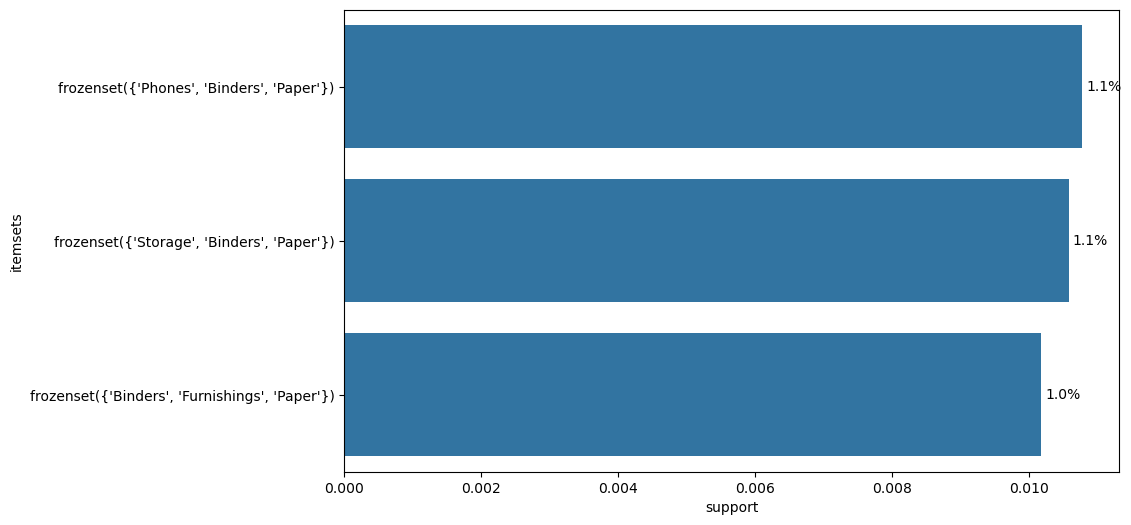

In [17]:
# Sorting and selecting top 10
fi3_top10 = fi3.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi3_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi3_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [18]:
fi= apriori(basket, min_support=.01, use_colnames= True)

In [19]:
ar= association_rules(fi, metric= 'lift', min_threshold=1)
ar= ar.iloc[:,:7]
ar= ar.sort_values('lift', ascending= False)
ar.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
38,"(Binders, Paper)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434
39,(Storage),"(Binders, Paper)",0.155121,0.054901,0.010581,0.068211,1.242434
32,"(Binders, Paper)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336
33,(Phones),"(Binders, Paper)",0.162507,0.054901,0.010781,0.066339,1.208336
31,"(Phones, Paper)",(Binders),0.034937,0.262727,0.010781,0.308571,1.174494


### Time Series Modeling

### EDA

In [20]:
df= df[['Order Date','Product Subcategory','Sales','Discount']]
df.head()

,Order Date,Product Subcategory,Sales,Discount
0,11/8/2017,Bookcases,261.9600,0.00
1,11/8/2017,Chairs,731.9400,0.00
2,6/12/2017,Labels,14.6200,0.00
3,10/11/2016,Tables,957.5775,0.45
4,10/11/2016,Storage,22.3680,0.20


In [21]:
df['Order Date']= pd.to_datetime(df['Order Date'])

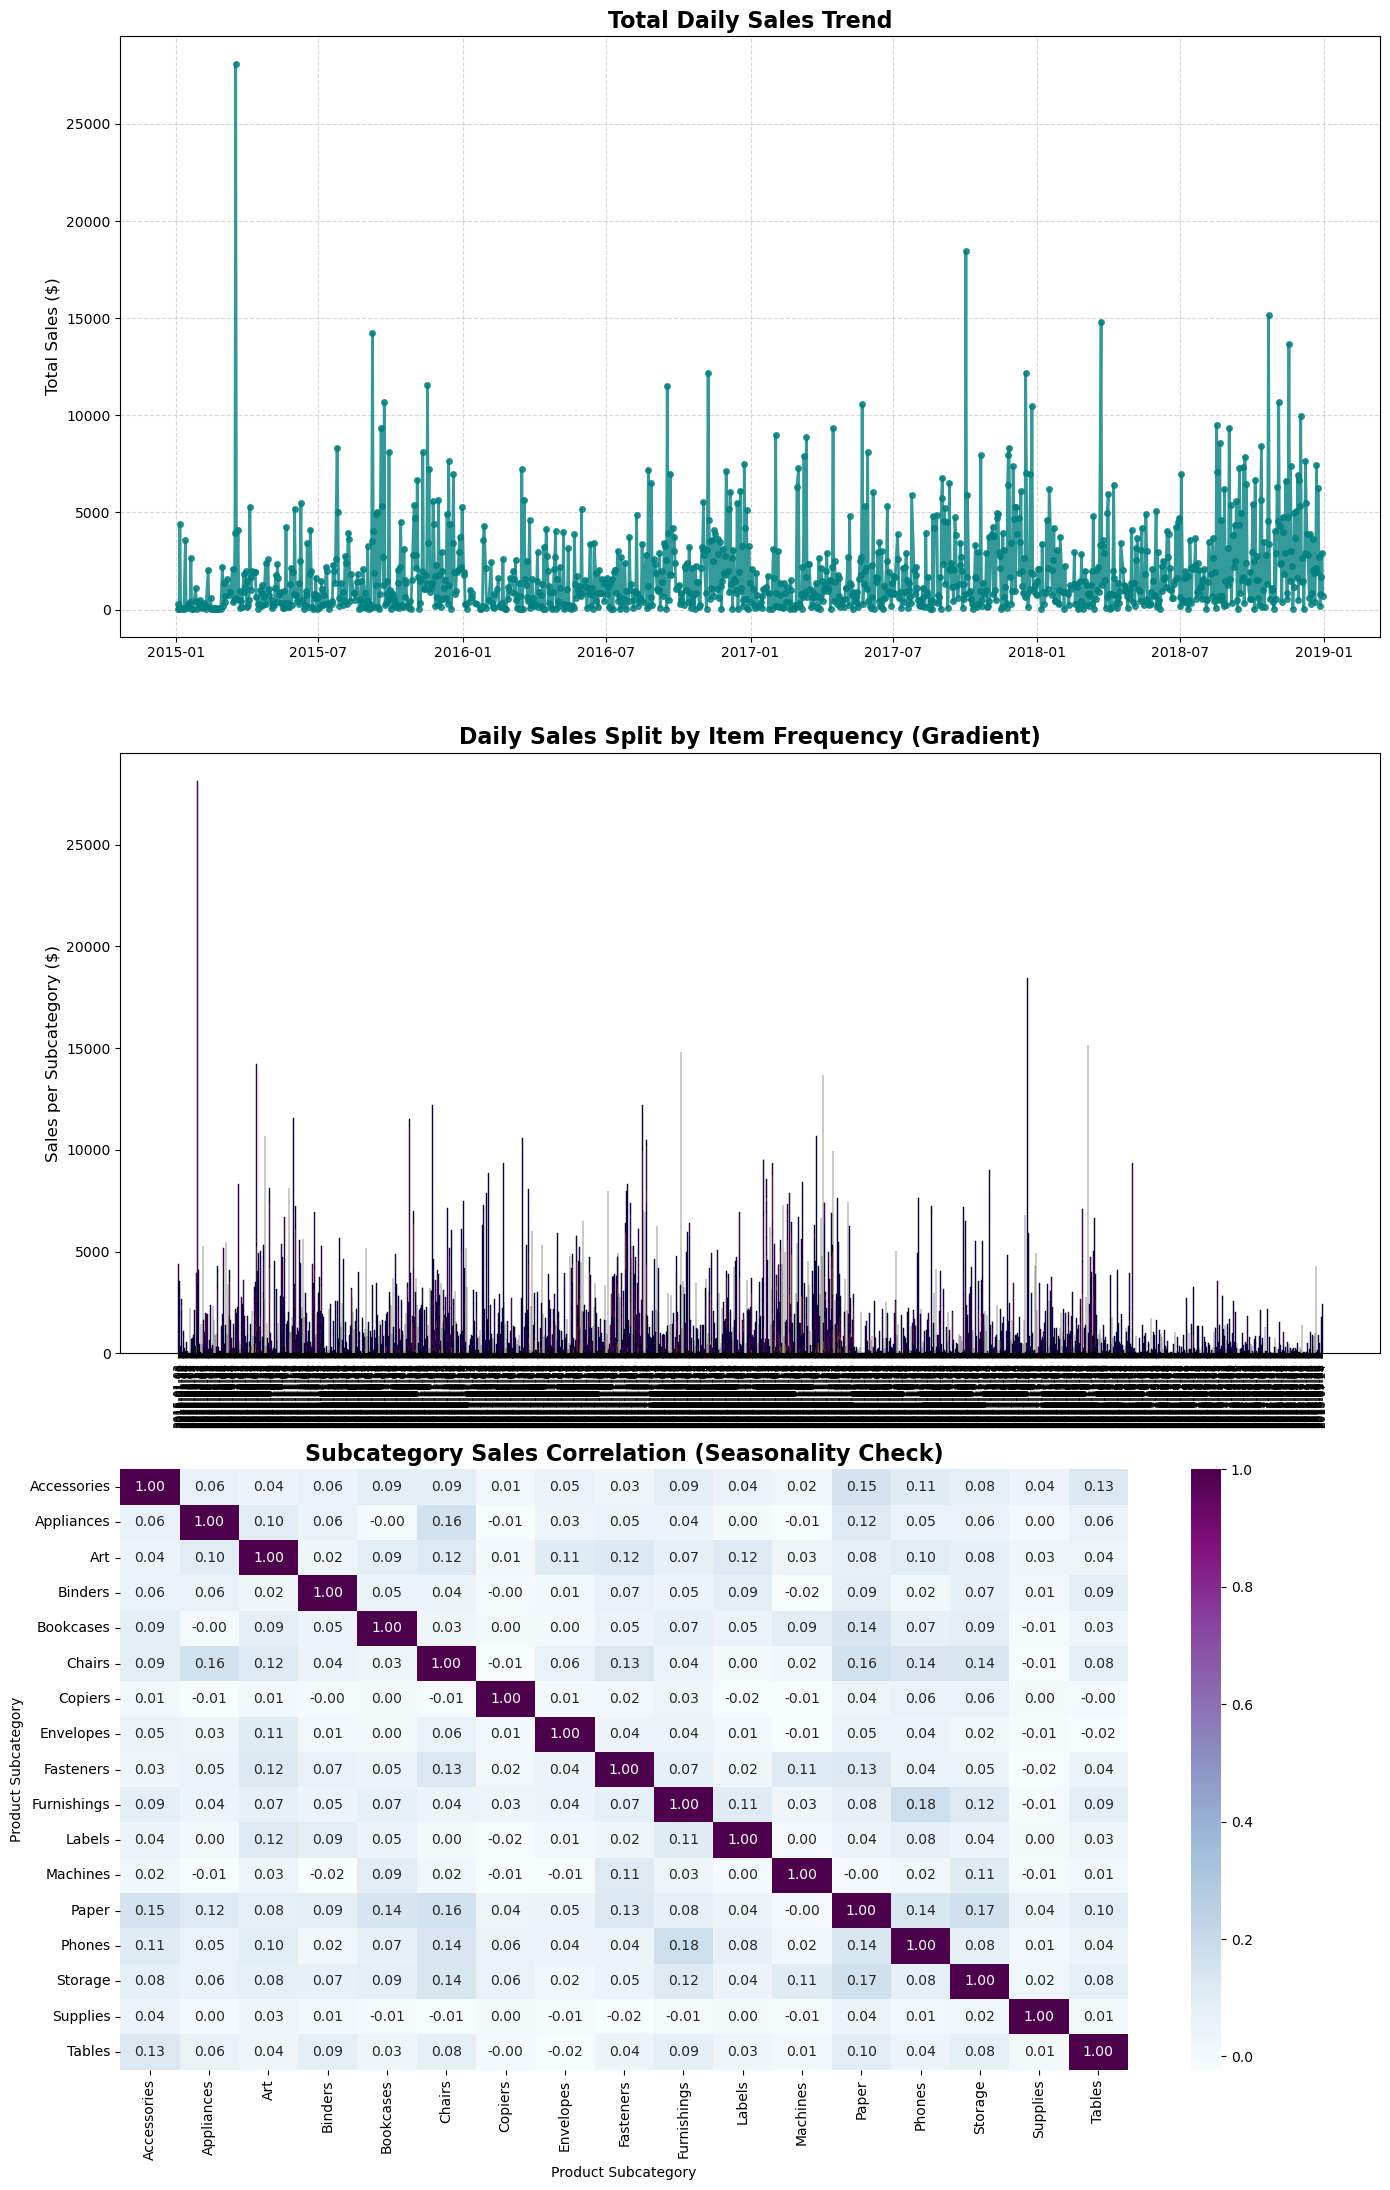

In [22]:
import numpy as np
import matplotlib.colors as mcolors

# Ensure 'Order Date' is datetime and sorted
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

# 1. Aggregating data
daily_sales = df.groupby('Order Date')['Sales'].sum()

# 2. Aggregating for the frequency-gradient bar plot
daily_item_stats = df.groupby(['Order Date', 'Product Subcategory']).agg(
    sales_sum=('Sales', 'sum'),
    item_freq=('Product Subcategory', 'count') 
).reset_index()

# 3. Pivot for correlation
pivot_df = df.pivot_table(index='Order Date', columns='Product Subcategory', values='Sales', aggfunc='sum').fillna(0)
corr_matrix = pivot_df.corr()

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(14, 22))

# Subplot 1: Daily Line Plot
axes[0].plot(daily_sales.index, daily_sales.values, color='#008080', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0].set_title('Total Daily Sales Trend', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Item Frequency Gradient Bar Chart
unique_dates = sorted(daily_item_stats['Order Date'].unique())
date_strs = [d.strftime('%Y-%m-%d') for d in unique_dates]
subcats = daily_item_stats['Product Subcategory'].unique()

norm = mcolors.Normalize(vmin=daily_item_stats['item_freq'].min(), vmax=daily_item_stats['item_freq'].max())
cmap = plt.cm.plasma
bottoms = np.zeros(len(unique_dates))

for sub in subcats:
    for i, d in enumerate(unique_dates):
        mask = (daily_item_stats['Order Date'] == d) & (daily_item_stats['Product Subcategory'] == sub)
        row = daily_item_stats[mask]
        if not row.empty:
            sales = row['sales_sum'].values[0]
            color = cmap(norm(row['item_freq'].values[0]))
            axes[1].bar(date_strs[i], sales, bottom=bottoms[i], color=color, edgecolor='black', linewidth=0.3)
            bottoms[i] += sales

axes[1].set_title('Daily Sales Split by Item Frequency (Gradient)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Sales per Subcategory ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

# Subplot 3: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='BuPu', ax=axes[2])
axes[2].set_title('Subcategory Sales Correlation (Seasonality Check)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

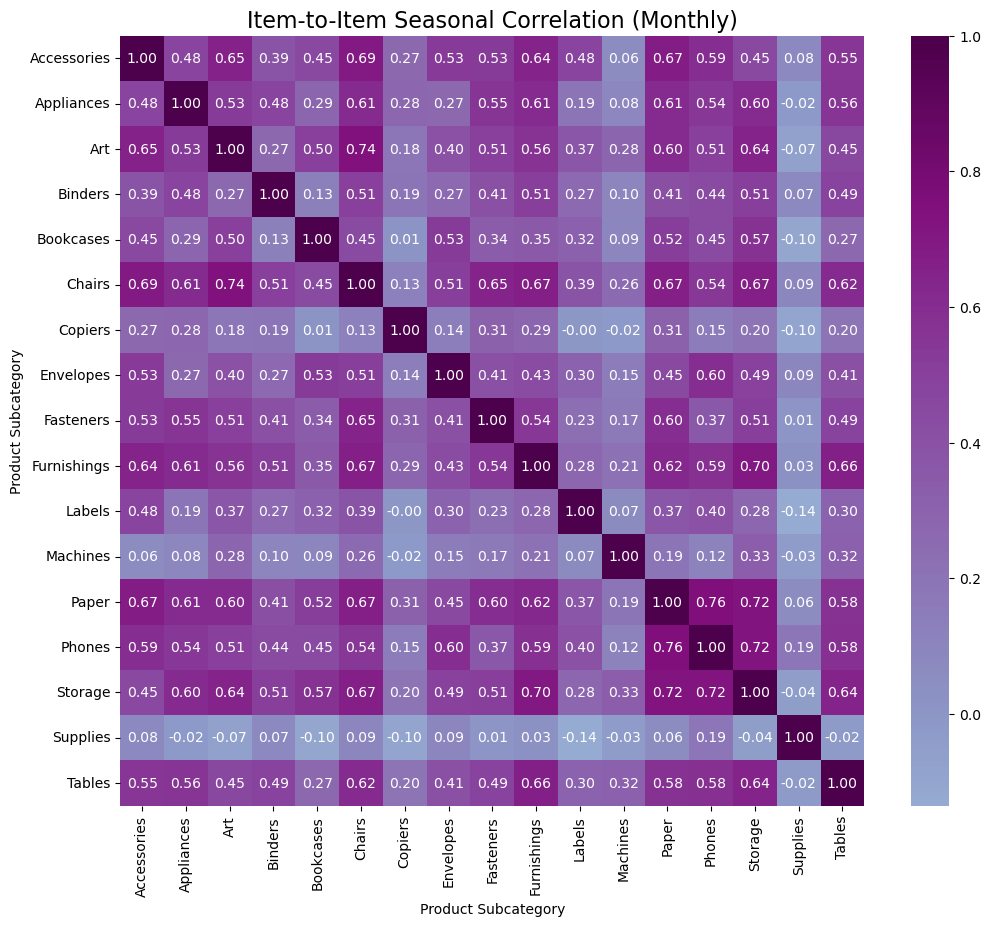

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the Index
# Ensure 'Order Date' is datetime and set as the index
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.set_index('Order Date', inplace=True)

# 2. Pivot: Aggregate Sales by Month ('M')
# Columns = Product Subcategory, Rows = Months
item_monthly_sales = df.pivot_table(index=df.index.to_period('M'), 
                                    columns='Product Subcategory', 
                                    values='Sales', 
                                    aggfunc='sum').fillna(0)

# 3. Compute Seasonal Correlation Matrix
# This calculates Pearson's r at a monthly granularity
item_corr = item_monthly_sales.corr()

# 4. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(item_corr, annot=True, fmt=".2f", cmap='BuPu', center=0)
plt.title("Item-to-Item Seasonal Correlation (Monthly)", fontsize=16)
plt.show()

In [24]:
# 1. Get unique dates from your data
unique_dates = df.index.unique()

# 2. Create the full expected range
full_range = pd.date_range(start='2015-01-03', end='2018-12-30')

# 3. Find missing days
missing_days = full_range.difference(unique_dates)

print(f"Total missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print(f"Sample missing days: {missing_days[:5]}")

Total missing days: 222
Sample missing days: DatetimeIndex(['2015-01-08', '2015-01-12', '2015-01-17', '2015-01-22',
               '2015-01-24'],
              dtype='datetime64[ns]', freq=None)


### Preprocessing

In [25]:
# 1. Pivot the data: Rows = Date, Columns = Subcategory, Values = Sales
# This makes the index UNIQUE (one row per day)
df_pivot = df.pivot_table(index='Order Date', 
                          columns='Product Subcategory', 
                          values='Sales', 
                          aggfunc='sum').fillna(0)

# 2. Now Reindex works! (1,458 rows x 17 subcategories)
full_range = pd.date_range(start='2015-01-03', end='2018-12-30')
df_final = df_pivot.reindex(full_range, fill_value=0)

# 3. Optional: Melt it back to "Long" format if you prefer that for XGBoost
df_long = df_final.reset_index().melt(id_vars='index', var_name='Subcategory', value_name='Sales')
df_long.rename(columns={'index': 'Order Date'}, inplace=True)

In [26]:
df_long.head()

,Order Date,Subcategory,Sales
0,2015-01-03,Accessories,0.0
1,2015-01-04,Accessories,0.0
2,2015-01-05,Accessories,0.0
3,2015-01-06,Accessories,0.0
4,2015-01-07,Accessories,0.0


C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\1999483290.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_res = temp_df['Sales'].resample('Y').sum()


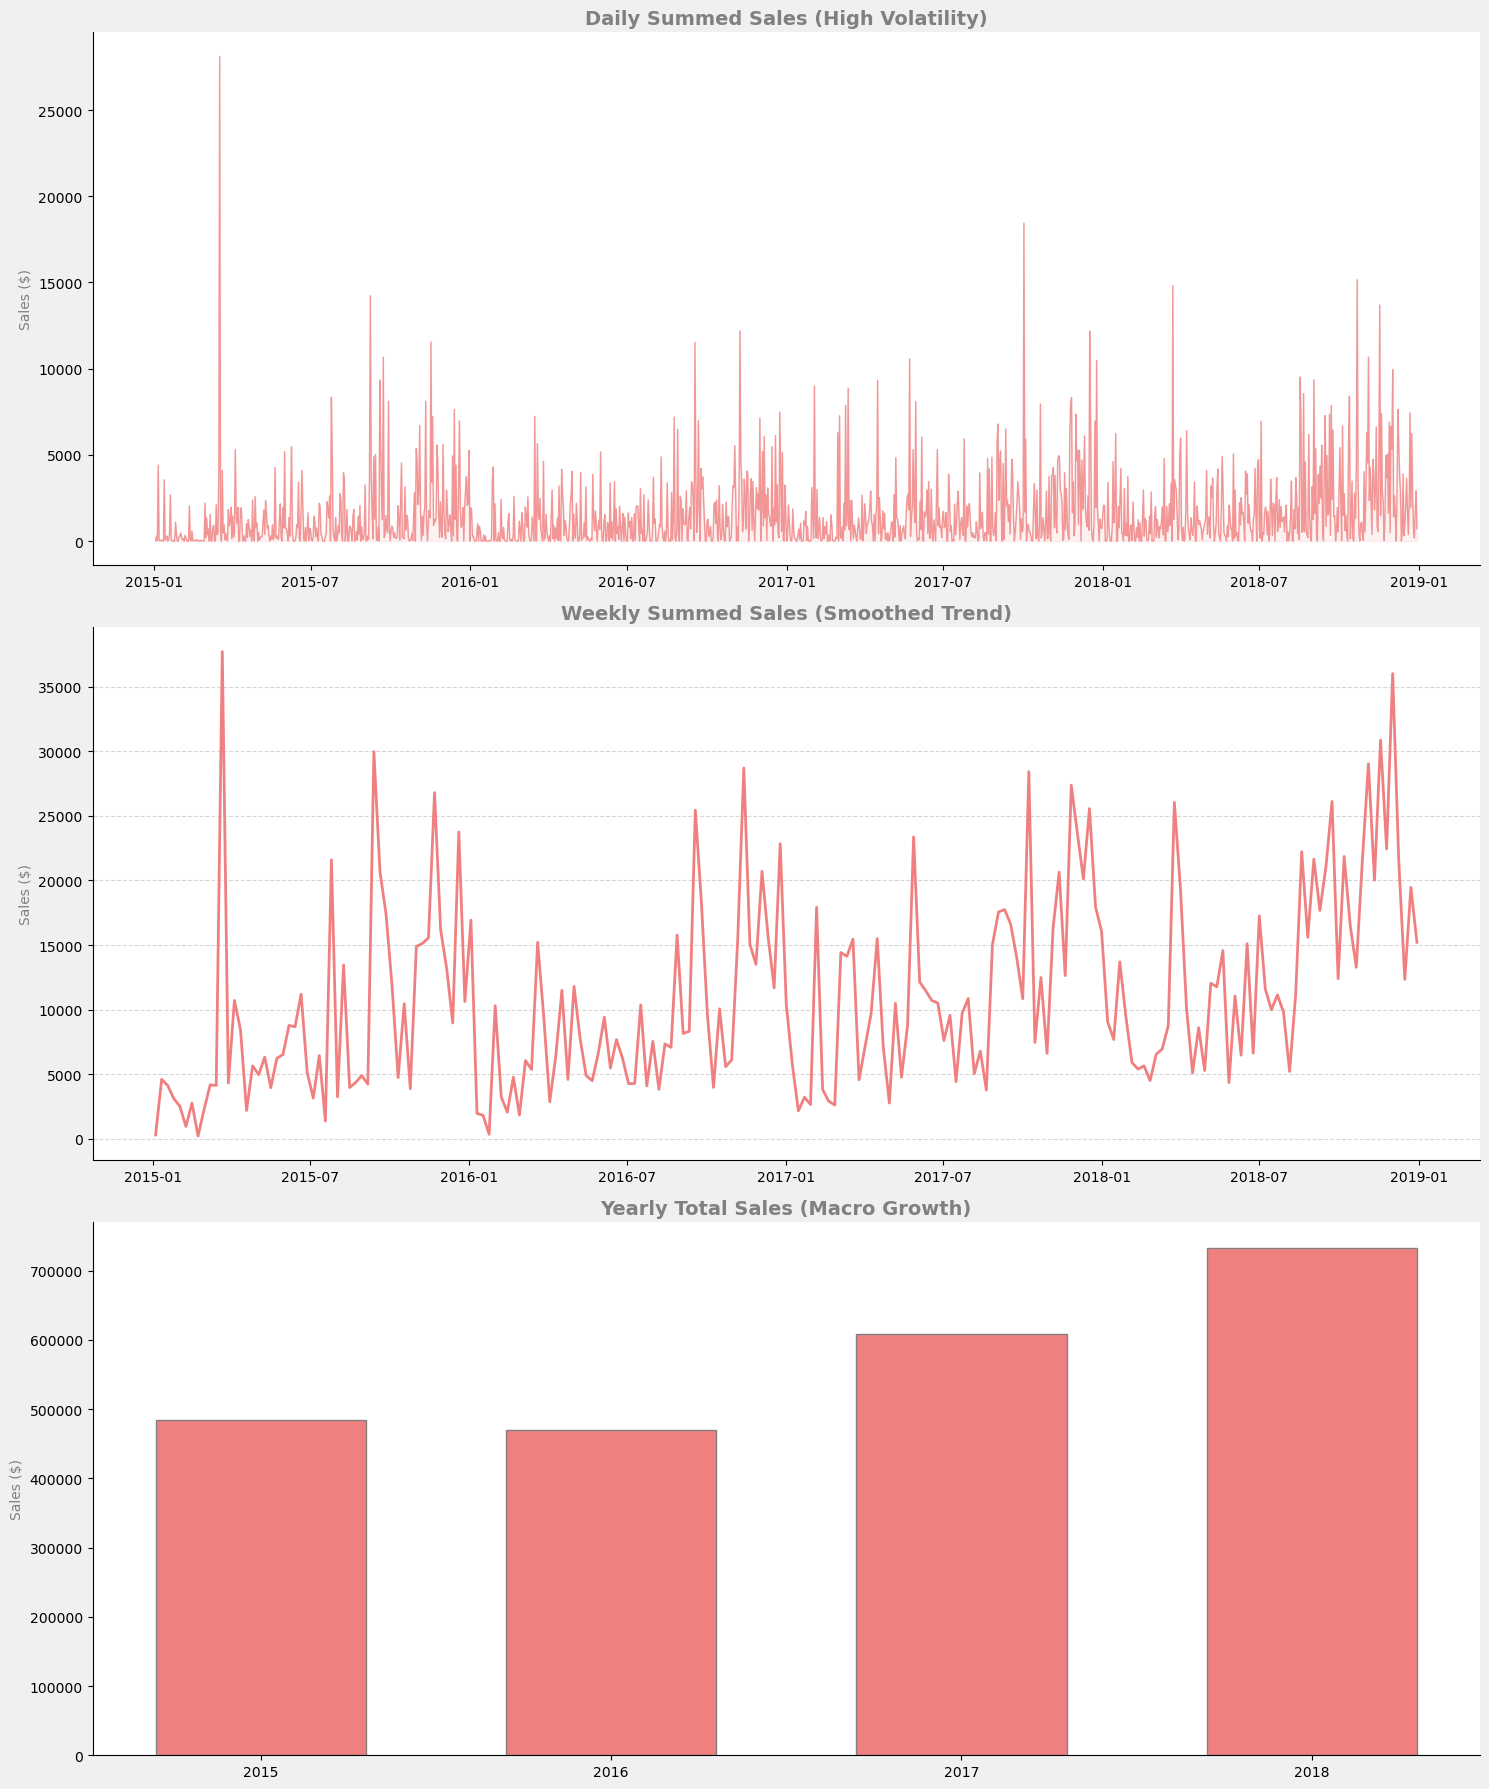

In [27]:
import matplotlib.pyplot as plt

# Ensure 'Order Date' is datetime and set as index for resampling
df_long['Order Date'] = pd.to_datetime(df_long['Order Date'])
temp_df = df_long.set_index('Order Date')

# Resampling data
# We group by the index and sum the sales for each period
daily_res = temp_df['Sales'].resample('D').sum()
weekly_res = temp_df['Sales'].resample('W').sum()
yearly_res = temp_df['Sales'].resample('Y').sum()

# Plotting Configuration
fig, axes = plt.subplots(3, 1, figsize=(15, 18), facecolor='#f0f0f0')
colors = {'red': '#f08080', 'gray': '#808080'} # Light milky red and gray

# --- Subplot 1: Daily Sales ---
axes[0].plot(daily_res.index, daily_res.values, color=colors['red'], linewidth=1, alpha=0.8)
axes[0].set_title('Daily Summed Sales (High Volatility)', fontsize=14, fontweight='bold', color=colors['gray'])
axes[0].fill_between(daily_res.index, daily_res.values, color=colors['red'], alpha=0.1)

# --- Subplot 2: Weekly Sales ---
axes[1].plot(weekly_res.index, weekly_res.values, color=colors['red'], linewidth=2)
axes[1].set_title('Weekly Summed Sales (Smoothed Trend)', fontsize=14, fontweight='bold', color=colors['gray'])
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Subplot 3: Yearly Sales ---
# Using a bar chart for yearly to emphasize annual totals
years = yearly_res.index.year.astype(str)
axes[2].bar(years, yearly_res.values, color=colors['red'], edgecolor=colors['gray'], width=0.6)
axes[2].set_title('Yearly Total Sales (Macro Growth)', fontsize=14, fontweight='bold', color=colors['gray'])

# Aesthetic adjustments
for ax in axes:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Sales ($)', color=colors['gray'])

plt.tight_layout()
plt.show()

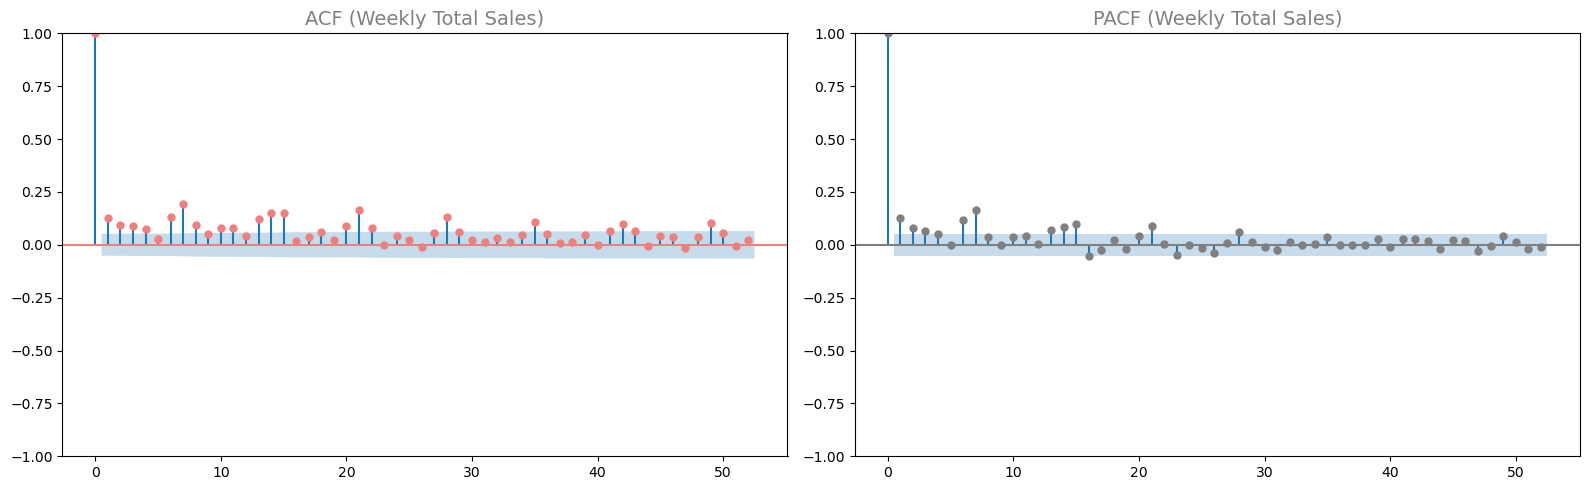

In [51]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Resample df_long to Weekly ('W') for each Subcategory
# Using 'Order Date' as index
df_weekly = df_long.set_index('Order Date').groupby('Subcategory')['Sales'].resample('D').sum().reset_index()

# 2. Pick a representative item or use the Total for the Global View
total_weekly = df_weekly.groupby('Order Date')['Sales'].sum()

# 3. Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(total_weekly, lags=52, ax=axes[0], color='#f08080') # Milky Red
axes[0].set_title('ACF (Weekly Total Sales)', fontsize=14, color='#808080')

plot_pacf(total_weekly, lags=52, ax=axes[1], color='#808080', method='ywm') # Gray
axes[1].set_title('PACF (Weekly Total Sales)', fontsize=14, color='#808080')

plt.tight_layout()
plt.show()

**based on pacf we'll use 1/2 lags per item, acf: we'll use 7 days moving average**

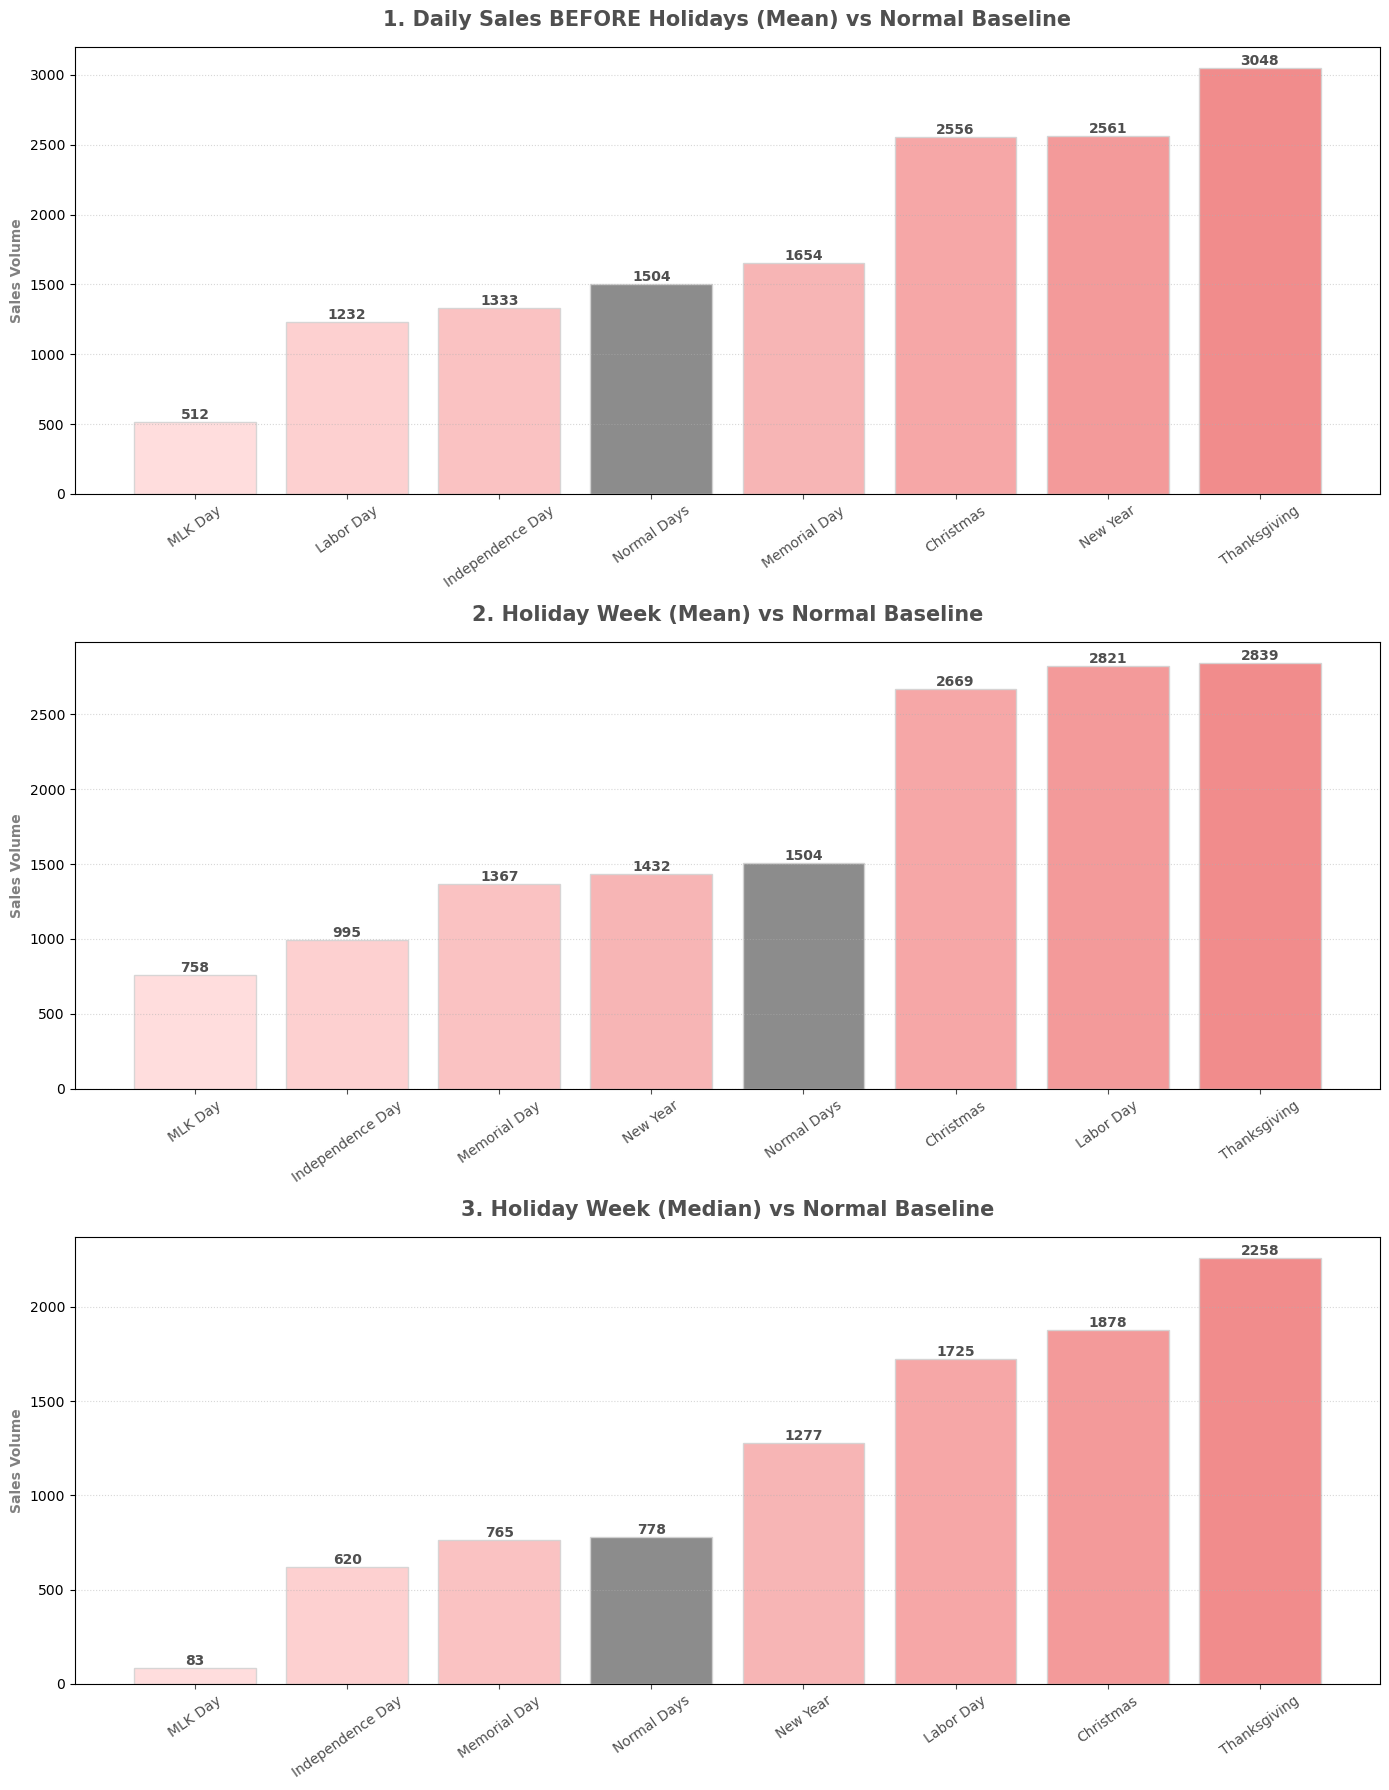

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- 1. PREP DATA ---
# Group df_long to get total daily sales (baseline for all items)
daily_sales = df_long.groupby('Order Date')['Sales'].sum()

# --- 2. DEFINE HOLIDAYS (2015-2018) ---
holidays_all = {
    'New Year': ['2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01'],
    'MLK Day': ['2015-01-19', '2016-01-18', '2017-01-16', '2018-01-15'],
    'Memorial Day': ['2015-05-25', '2016-05-30', '2017-05-29', '2018-05-28'],
    'Independence Day': ['2015-07-04', '2016-07-04', '2017-07-04', '2018-07-04'],
    'Labor Day': ['2015-09-07', '2016-09-05', '2017-09-04', '2018-09-03'],
    'Thanksgiving': ['2015-11-26', '2016-11-24', '2017-11-23', '2018-11-22'],
    'Christmas': ['2015-12-25', '2016-12-25', '2017-12-25', '2018-12-25']
}

h_windows, p_windows, excluded = {}, {}, []

for name, dates in holidays_all.items():
    h_list, p_list = [], []
    for d in dates:
        center = pd.to_datetime(d)
        if center not in daily_sales.index: continue
        
        # Holiday: +/- 3 days | Pre-holiday: days -10 to -4
        h_s, h_e = center - pd.Timedelta(days=3), center + pd.Timedelta(days=3)
        p_s, p_e = center - pd.Timedelta(days=10), center - pd.Timedelta(days=4)
        
        h_data = daily_sales[h_s:h_e]
        p_data = daily_sales[p_s:p_e]
        
        if not h_data.empty: h_list.extend(h_data.values)
        if not p_data.empty: p_list.extend(p_data.values)
        excluded.extend(pd.date_range(p_s, h_e))

    if h_list: h_windows[name] = np.mean(h_list)
    if p_list: p_windows[name] = np.mean(p_list)

# --- 3. BASELINE ---
normal_days = daily_sales.drop(pd.to_datetime(list(set(excluded))), errors='ignore')

# --- 4. FORMATTING TOOLS ---
red_cmap = mcolors.LinearSegmentedColormap.from_list("milk_red", ["#FFDADA", "#F08080"])

def get_bar_colors(series):
    n_hols = len(series) - 1
    gradient = [red_cmap(i/max(1, n_hols-1)) for i in range(n_hols)]
    cols, g_idx = [], 0
    for label in series.index:
        if label == 'Normal Days':
            cols.append('#808080')
        else:
            cols.append(gradient[g_idx])
            g_idx += 1
    return cols

def draw_formatted_bars(ax, data, title):
    bar_cols = get_bar_colors(data)
    bars = ax.bar(data.index, data.values, color=bar_cols, edgecolor='#D3D3D3', alpha=0.9)
    ax.set_title(title, fontsize=15, color='#4F4F4F', fontweight='bold', pad=15)
    ax.set_ylabel('Sales Volume', color='#808080', fontweight='bold')
    ax.tick_params(axis='x', rotation=35, colors='#4F4F4F')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f'{int(h)}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4F4F4F')

# --- 5. SERIES FOR PLOTTING ---
s1 = pd.Series({**p_windows, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s2 = pd.Series({**h_windows, 'Normal Days': normal_days.mean()}).dropna().sort_values()
# For Median: recalculate from raw lists to be precise
h_medians = {name: np.median([v for d in dates for v in daily_sales[pd.to_datetime(d)-pd.Timedelta(days=3):pd.to_datetime(d)+pd.Timedelta(days=3)] if not daily_sales[pd.to_datetime(d)-pd.Timedelta(days=3):pd.to_datetime(d)+pd.Timedelta(days=3)].empty]) for name, dates in holidays_all.items()}
s3 = pd.Series({**h_medians, 'Normal Days': normal_days.median()}).dropna().sort_values()

# --- 6. PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(14, 18), facecolor='white')

draw_formatted_bars(axes[0], s1, '1. Daily Sales BEFORE Holidays (Mean) vs Normal Baseline')
draw_formatted_bars(axes[1], s2, '2. Holiday Week (Mean) vs Normal Baseline')
draw_formatted_bars(axes[2], s3, '3. Holiday Week (Median) vs Normal Baseline')

plt.tight_layout()
plt.show()

**holidays show clear increase in sales versus regular days, we'll engineer them in features**

****

### Feature engineering

In [30]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from pandas.tseries.holiday import USFederalHolidayCalendar

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.holidays = None

    def fit(self, X, y=None):
        cal = USFederalHolidayCalendar()
        start, end = X['Order Date'].min(), X['Order Date'].max() + pd.Timedelta(days=365)
        self.holidays = cal.holidays(start=start, end=end)
        return self

    def transform(self, X):
        X = X.copy()
        X['day_of_week'] = X['Order Date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['Order Date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['Order Date'].dt.month / 12)
        X['is_holiday'] = X['Order Date'].isin(self.holidays).astype(int)
        X['to_holiday'] = X['Order Date'].apply(lambda d: (self.holidays[self.holidays >= d].min() - d).days 
                                                if not self.holidays[self.holidays >= d].empty else 365)
        
        if 'Sales' in X.columns:
            X = X.sort_values(['Subcategory', 'Order Date'])
            grouped = X.groupby('Subcategory')['Sales']
            for l in [1, 2, 7]:
                X[f'lag_{l}'] = grouped.shift(l)
            X['roll_mean_7'] = grouped.transform(lambda x: x.shift(1).rolling(7).mean())
            X['roll_std_7'] = grouped.transform(lambda x: x.shift(1).rolling(7).std())
            X = X.drop(columns=['Sales'])

        if 'Order Date' in X.columns:
            X = X.drop(columns=['Order Date'])
        return X.fillna(0)

class ColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column_name, categories):
        self.column_name = column_name
        self.categories = categories
        self.le = LabelEncoder()
        # Pre-fit on the global universe of categories
        self.le.fit(self.categories)

    def fit(self, X, y=None):
        return self # Already fitted in __init__

    def transform(self, X):
        X = X.copy()
        # Map unknown labels to a placeholder if they somehow still appear
        X[self.column_name] = X[self.column_name].apply(
            lambda x: x if x in self.le.classes_ else self.le.classes_[0]
        )
        X[self.column_name] = self.le.transform(X[self.column_name])
        return X

### Preprocessing

In [31]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Define the Global Universe of categories
all_subcategories = df_long['Subcategory'].unique()

# 2. Manual Setup for the Evaluator (The Brute Force)
eng = TimeSeriesFeatureEngineer().fit(df_long)
enc = ColumnLabelEncoder(column_name='Subcategory', categories=all_subcategories)

# 3. Data Splitting
X_all = df_long.copy()
y_all = df_long['Sales']
tscv = TimeSeriesSplit(n_splits=3)

for train_idx, test_idx in tscv.split(X_all):
    X_train_cv, X_test_cv = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train_cv, y_test_cv = y_all.iloc[train_idx], y_all.iloc[test_idx]

# 4. Transform Test Set for Early Stopping using the Manual instances
X_test_transformed = enc.transform(eng.transform(X_test_cv))

### Model Selection

In [32]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

# 1. Define Model
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=1000, 
    early_stopping_rounds=50, 
    random_state=42, 
    n_jobs=-1
)

# 2. Pipeline (Using the universe-aware encoder)
search_pipe = Pipeline([
    ('engineer', TimeSeriesFeatureEngineer()),
    ('encoder', ColumnLabelEncoder(column_name='Subcategory', categories=all_subcategories)),
    ('model', xgb_reg)
])

# 3. Randomized Search
params = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 0.9]
}

random_search = RandomizedSearchCV(
    search_pipe, 
    param_distributions=params, 
    n_iter=10, 
    cv=tscv, 
    scoring='neg_root_mean_squared_error', 
    random_state=42
)

# 4. THE FINAL FIT
random_search.fit(
    X_train_cv, y_train_cv, 
    model__eval_set=[(X_test_transformed, y_test_cv)], 
    model__verbose=False
)

# 5. TEST & RMSE
y_pred = random_search.predict(X_test_cv)
rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred))

print(f"\n--- MISSION SUCCESSFUL ---")
print(f"Final Test RMSE: {rmse:.2f}")
print(f"Best Depth: {random_search.best_params_['model__max_depth']}")


--- MISSION SUCCESSFUL ---
Final Test RMSE: 412.70
Best Depth: 3


### Model Eval

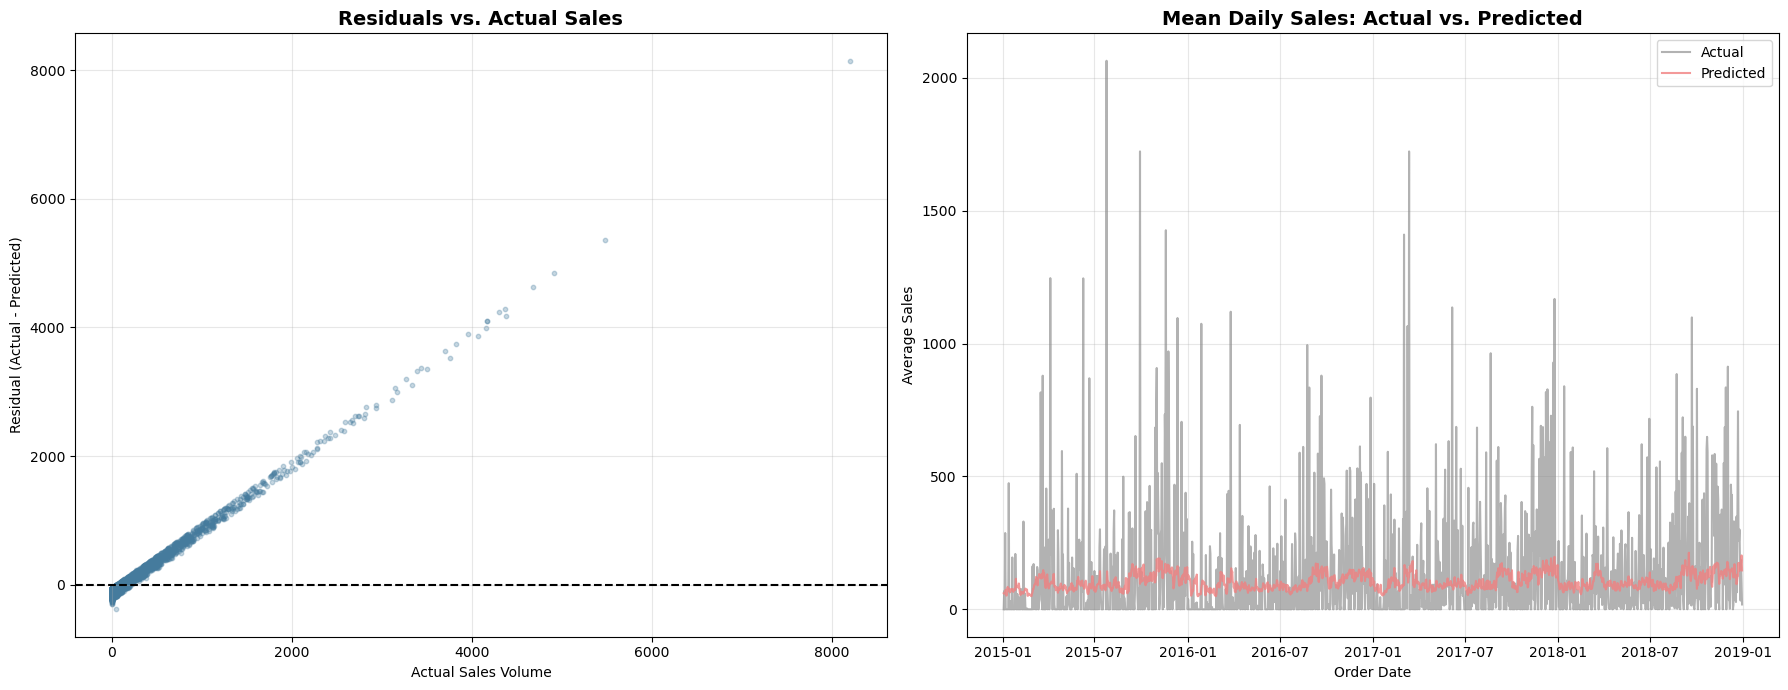

In [33]:
import matplotlib.pyplot as plt

# 1. Calculate Residuals
test_residuals = y_test_cv - y_pred

# 2. Setup Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# --- Subplot 1: Residuals vs. Actual Sales ---
# Checks for heteroscedasticity (error variance changing with scale)
ax1.scatter(y_test_cv, test_residuals, alpha=0.3, color='#457B9D', s=10)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.set_title("Residuals vs. Actual Sales", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Sales Volume")
ax1.set_ylabel("Residual (Actual - Predicted)")
ax1.grid(alpha=0.3)

# --- Subplot 2: Actual vs. Predicted over Time ---
# Grouping by 'Order Date' from your test set
test_dates = X_test_cv['Order Date']
daily_actual = pd.DataFrame({'date': test_dates, 'sales': y_test_cv}).groupby('date')['sales'].mean()
daily_pred = pd.DataFrame({'date': test_dates, 'sales': y_pred}).groupby('date')['sales'].mean()

ax2.plot(daily_actual.index, daily_actual.values, color='#808080', alpha=0.6, label='Actual', linewidth=1.5)
ax2.plot(daily_pred.index, daily_pred.values, color='#F08080', alpha=0.8, label='Predicted', linewidth=1.5)

ax2.set_title("Mean Daily Sales: Actual vs. Predicted", fontsize=14, fontweight='bold')
ax2.set_xlabel("Order Date")
ax2.set_ylabel("Average Sales")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# items to bundle
# are frequent items profitable
# by using quantity and profit average out sale price for each item

### USING QUANTITY AS TARGET (Y)

In [38]:
df= data.copy()
df= df[['Order Date','Product Subcategory','Sales','Quantity','Discount', 'Profit']]
df['Order Date']= pd.to_datetime(df['Order Date'])
df.head()

,Order Date,Product Subcategory,Sales,Quantity,Discount,Profit
0,2017-11-08,Bookcases,261.9600,2,0.00,41.9136
1,2017-11-08,Chairs,731.9400,3,0.00,219.5820
2,2017-06-12,Labels,14.6200,2,0.00,6.8714
3,2016-10-11,Tables,957.5775,5,0.45,-383.0310
4,2016-10-11,Storage,22.3680,2,0.20,2.5164


In [40]:
import pandas as pd

# 1. Convert and get range
df['Order Date'] = pd.to_datetime(df['Order Date'])
all_dates = pd.date_range(start='2015-01-03', end='2018-12-30', freq='D')
all_subcats = df['Product Subcategory'].unique()

# 2. Create the "Master Grid"
grid = pd.MultiIndex.from_product([all_dates, all_subcats], names=['Order Date', 'Product Subcategory']).to_frame(index=False)

# 3. Merge original data into the grid
df_complete = pd.merge(grid, df, on=['Order Date', 'Product Subcategory'], how='left')

# 4. Impute zeros for missing sales days
fill_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df_complete[fill_cols] = df_complete[fill_cols].fillna(0)

# 5. Sort and Index
df_complete = df_complete.sort_values(['Order Date', 'Product Subcategory']).set_index('Order Date')

In [41]:
import numpy as np

# Avoid division by zero by replacing 0 quantity/sales with NaN temporarily
temp_df = df_complete.copy()
temp_df[['Sales', 'Quantity']] = temp_df[['Sales', 'Quantity']].replace(0, np.nan)

# Calculate the Base Price (before discount) for every transaction
temp_df['base_unit_price'] = temp_df['Sales'] / (temp_df['Quantity'] * (1 - temp_df['Discount']))

# Calculate the Unit Cost (incorporating Profit)
temp_df['unit_cost'] = (temp_df['Sales'] - temp_df['Profit']) / temp_df['Quantity']

# Create a reference table of Median Base Prices (The 'orig_price' for the future)
orig_price_map = temp_df.groupby('Product Subcategory')[['base_unit_price', 'unit_cost']].median()

# Map these back to our main dataframe as a reference feature
df_complete = df_complete.join(orig_price_map, on='Product Subcategory', rsuffix='_ref')

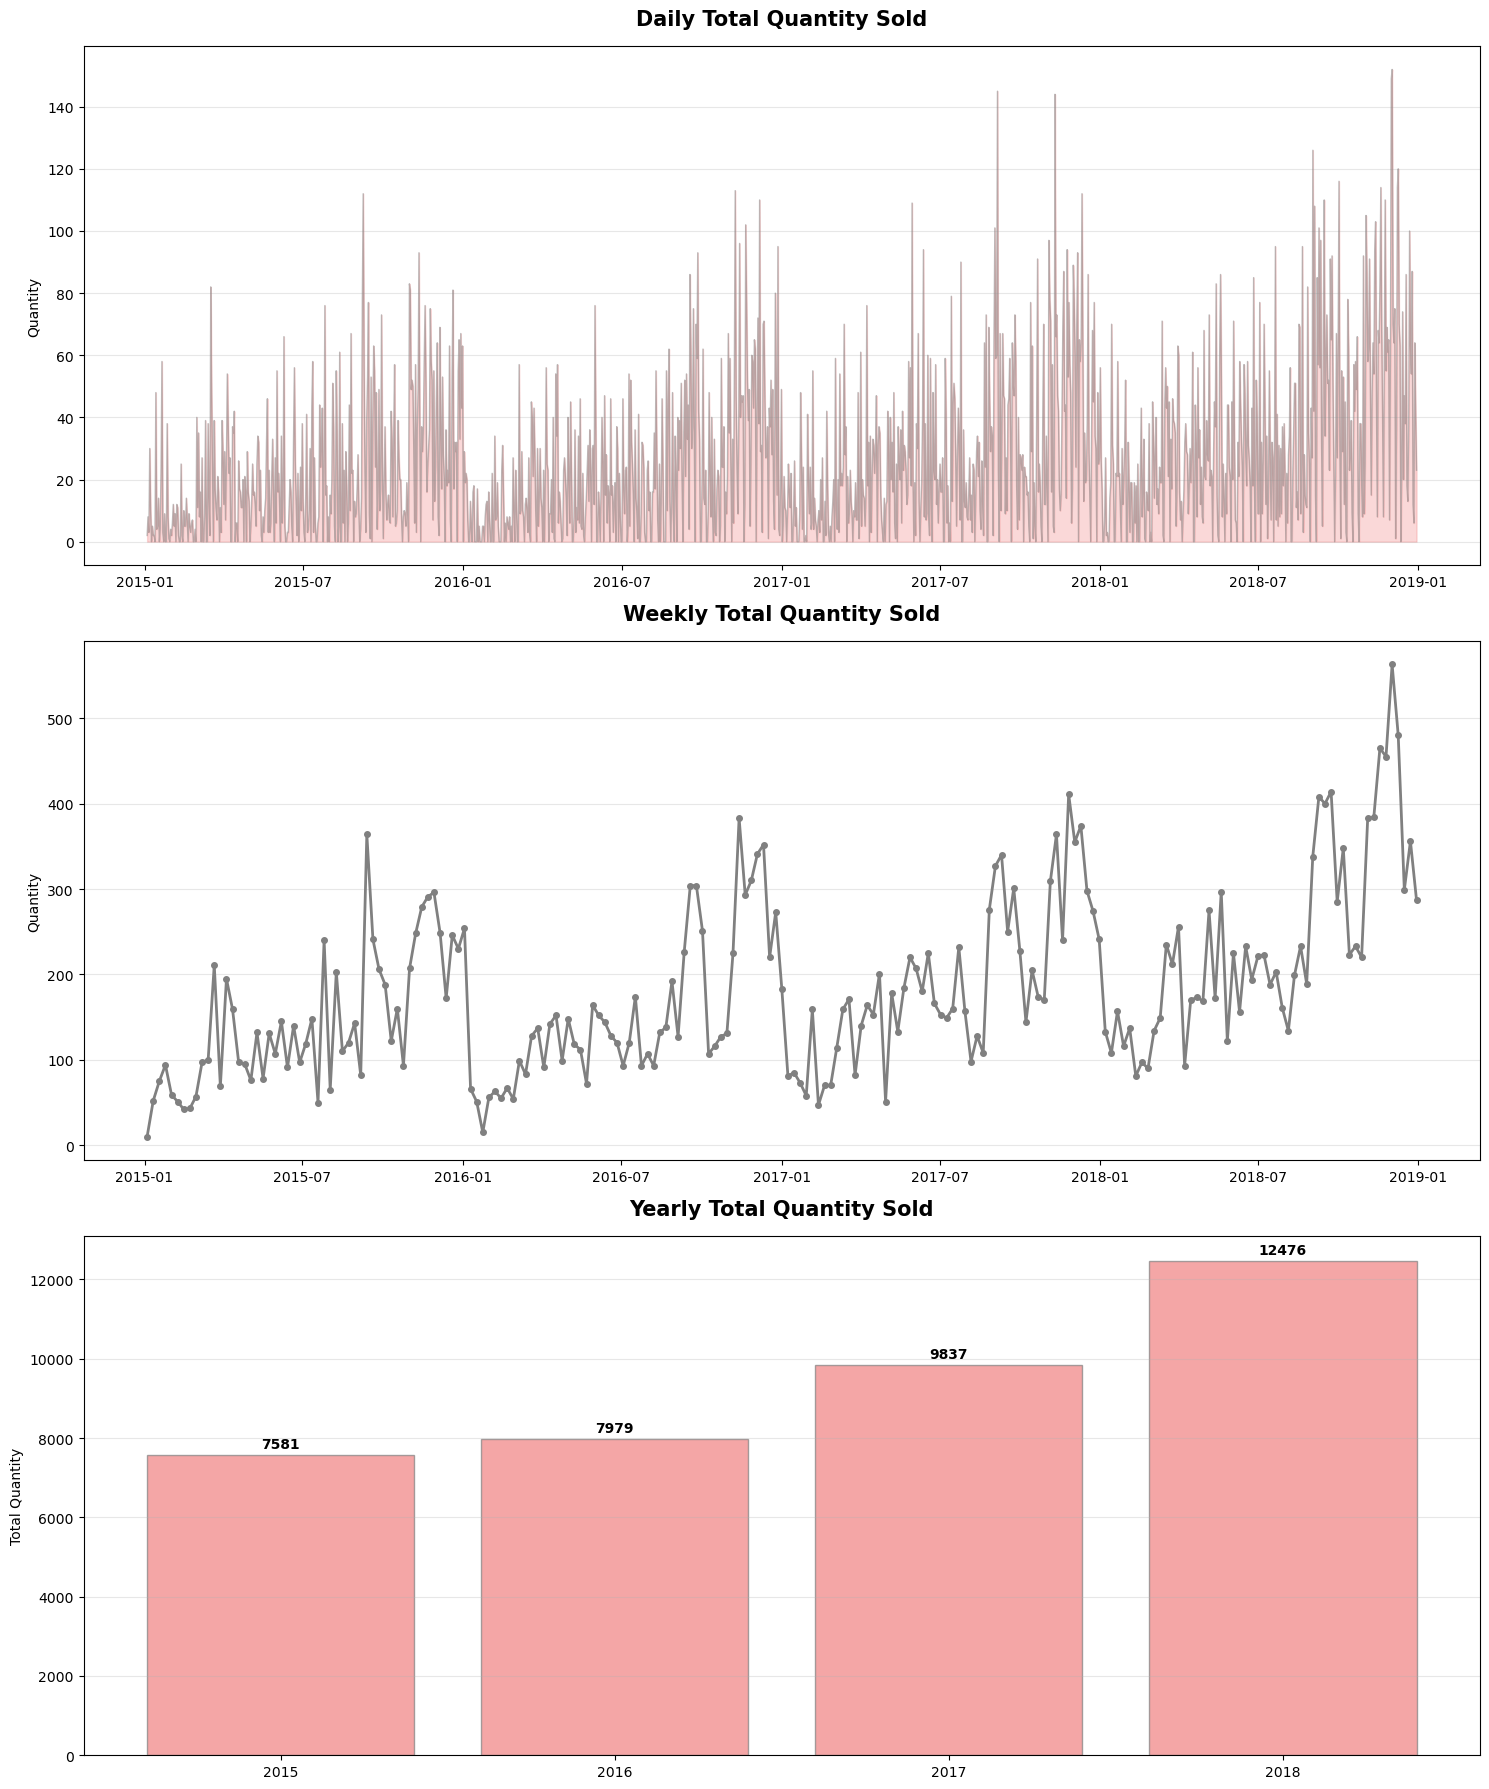

In [44]:
import matplotlib.pyplot as plt

# 1. Resample data for different time horizons
# 'D' = Daily, 'W' = Weekly, 'YE' = Year End (formerly 'A' or 'Y')
daily_qty = df_complete['Quantity'].resample('D').sum()
weekly_qty = df_complete['Quantity'].resample('W').sum()
yearly_qty = df_complete['Quantity'].resample('YE').sum()

# 2. Setup Plot (3 rows, 1 column)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='white')
colors = {'red': '#F08080', 'gray': '#808080'}

# --- Subplot 1: Daily Quantity (The Pulse) ---
ax1.plot(daily_qty.index, daily_qty.values, color=colors['gray'], alpha=0.5, linewidth=1)
ax1.fill_between(daily_qty.index, daily_qty.values, color=colors['red'], alpha=0.3)
ax1.set_title("Daily Total Quantity Sold", fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel("Quantity")
ax1.grid(axis='y', alpha=0.3)

# --- Subplot 2: Weekly Quantity (The Rhythm) ---
ax2.plot(weekly_qty.index, weekly_qty.values, color=colors['gray'], marker='o', markersize=4, linewidth=2)
ax2.set_title("Weekly Total Quantity Sold", fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel("Quantity")
ax2.grid(axis='y', alpha=0.3)

# --- Subplot 3: Yearly Quantity (The Growth) ---
bars = ax3.bar(yearly_qty.index.year.astype(str), yearly_qty.values, color=colors['red'], alpha=0.7, edgecolor=colors['gray'])
ax3.set_title("Yearly Total Quantity Sold", fontsize=15, fontweight='bold', pad=15)
ax3.set_ylabel("Total Quantity")
ax3.grid(axis='y', alpha=0.3)

# Add data labels to the yearly bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 100, f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**investigating holidays sales spikes**

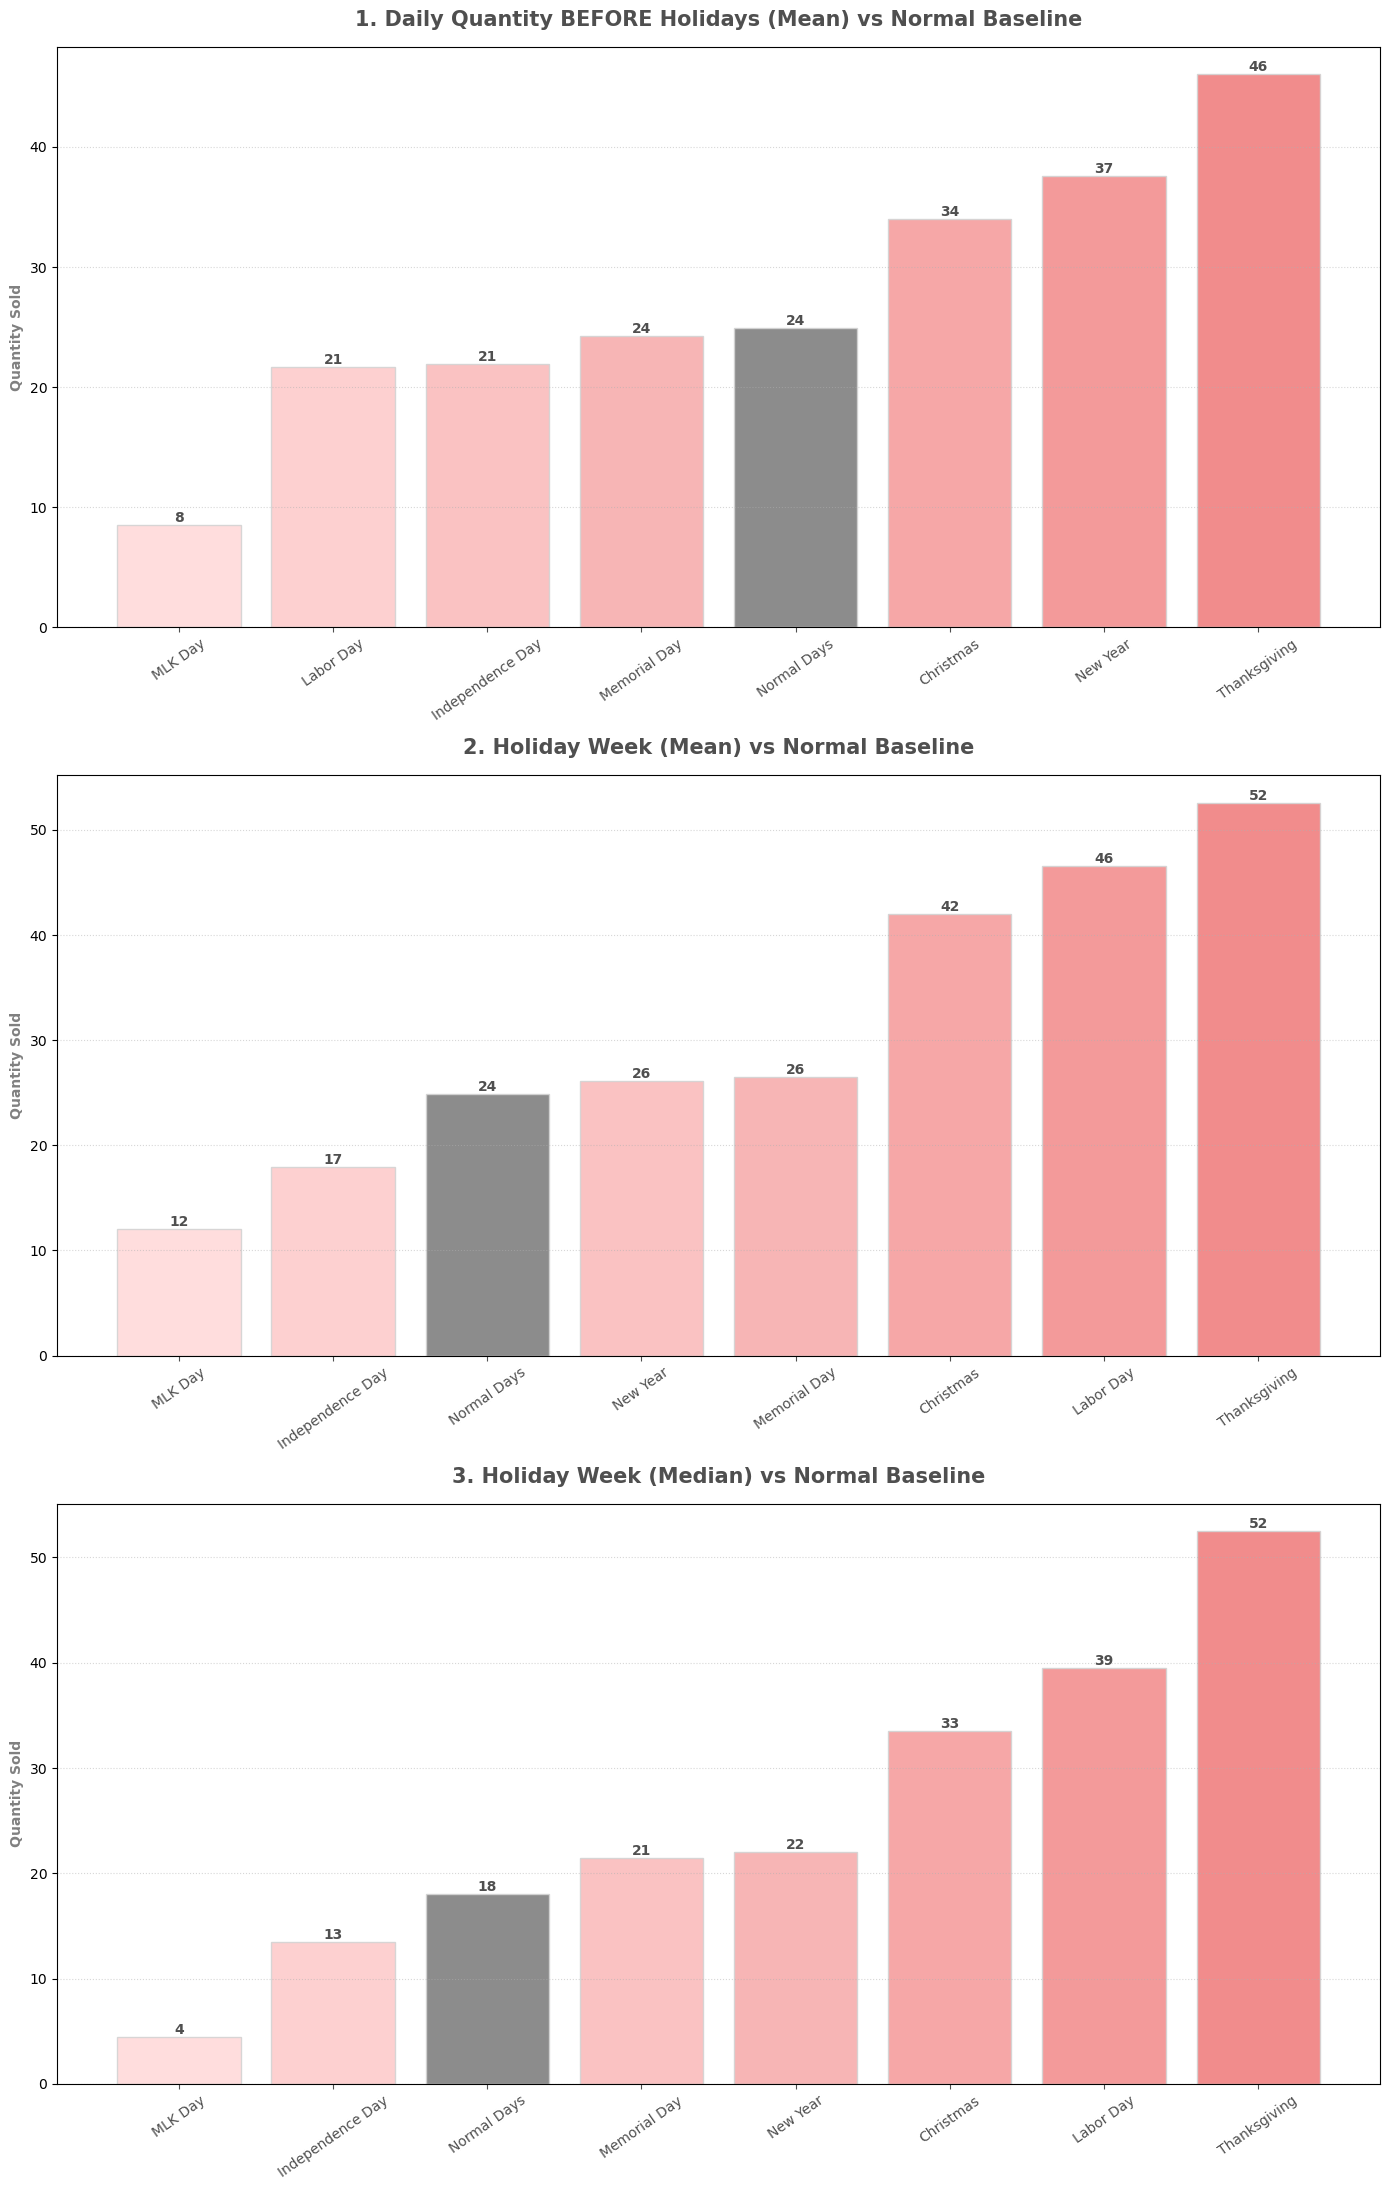

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- 1. PREP DATA ---
# Using the daily quantity from our complete grid
daily_qty = df_complete.groupby('Order Date')['Quantity'].sum()

# --- 2. DEFINE HOLIDAYS (2015-2018) ---
holidays_all = {
    'New Year': ['2015-01-01', '2016-01-01', '2017-01-01', '2018-01-01'],
    'MLK Day': ['2015-01-19', '2016-01-18', '2017-01-16', '2018-01-15'],
    'Memorial Day': ['2015-05-25', '2016-05-30', '2017-05-29', '2018-05-28'],
    'Independence Day': ['2015-07-04', '2016-07-04', '2017-07-04', '2018-07-04'],
    'Labor Day': ['2015-09-07', '2016-09-05', '2017-09-04', '2018-09-03'],
    'Thanksgiving': ['2015-11-26', '2016-11-24', '2017-11-23', '2018-11-22'],
    'Christmas': ['2015-12-25', '2016-12-25', '2017-12-25', '2018-12-25']
}

h_means, p_means, h_medians, excluded = {}, {}, {}, []

for name, dates in holidays_all.items():
    h_list, p_list = [], []
    for d in dates:
        center = pd.to_datetime(d)
        if center not in daily_qty.index: continue
        
        # Holiday: +/- 3 days | Pre-holiday: days -10 to -4
        h_s, h_e = center - pd.Timedelta(days=3), center + pd.Timedelta(days=3)
        p_s, p_e = center - pd.Timedelta(days=10), center - pd.Timedelta(days=4)
        
        h_data = daily_qty[h_s:h_e]
        p_data = daily_qty[p_s:p_e]
        
        if not h_data.empty: h_list.extend(h_data.values)
        if not p_data.empty: p_list.extend(p_data.values)
        excluded.extend(pd.date_range(p_s, h_e))

    if h_list: 
        h_means[name] = np.mean(h_list)
        h_medians[name] = np.median(h_list)
    if p_list: 
        p_means[name] = np.mean(p_list)

# --- 3. BASELINE ---
normal_days = daily_qty.drop(pd.to_datetime(list(set(excluded))), errors='ignore')

# --- 4. FORMATTING TOOLS ---
red_cmap = mcolors.LinearSegmentedColormap.from_list("milk_red", ["#FFDADA", "#F08080"])

def get_bar_colors(series):
    n_hols = len(series) - 1
    gradient = [red_cmap(i/max(1, n_hols-1)) for i in range(n_hols)]
    cols, g_idx = [], 0
    for label in series.index:
        if label == 'Normal Days':
            cols.append('#808080')
        else:
            cols.append(gradient[g_idx])
            g_idx += 1
    return cols

def draw_formatted_bars(ax, data, title):
    bar_cols = get_bar_colors(data)
    bars = ax.bar(data.index, data.values, color=bar_cols, edgecolor='#D3D3D3', alpha=0.9)
    ax.set_title(title, fontsize=15, color='#4F4F4F', fontweight='bold', pad=15)
    ax.set_ylabel('Quantity Sold', color='#808080', fontweight='bold')
    ax.tick_params(axis='x', rotation=35, colors='#4F4F4F')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f'{int(h)}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4F4F4F')

# --- 5. SERIES FOR PLOTTING ---
s1 = pd.Series({**p_means, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s2 = pd.Series({**h_means, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s3 = pd.Series({**h_medians, 'Normal Days': normal_days.median()}).dropna().sort_values()

# --- 6. PLOTTING ---
fig, axes = plt.subplots(3, 1, figsize=(14, 22), facecolor='white')

draw_formatted_bars(axes[0], s1, '1. Daily Quantity BEFORE Holidays (Mean) vs Normal Baseline')
draw_formatted_bars(axes[1], s2, '2. Holiday Week (Mean) vs Normal Baseline')
draw_formatted_bars(axes[2], s3, '3. Holiday Week (Median) vs Normal Baseline')

plt.tight_layout()
plt.show()

**strong evidence suggesting spikes in holidays (adding features to incorporate that)**

**acf and pacf**

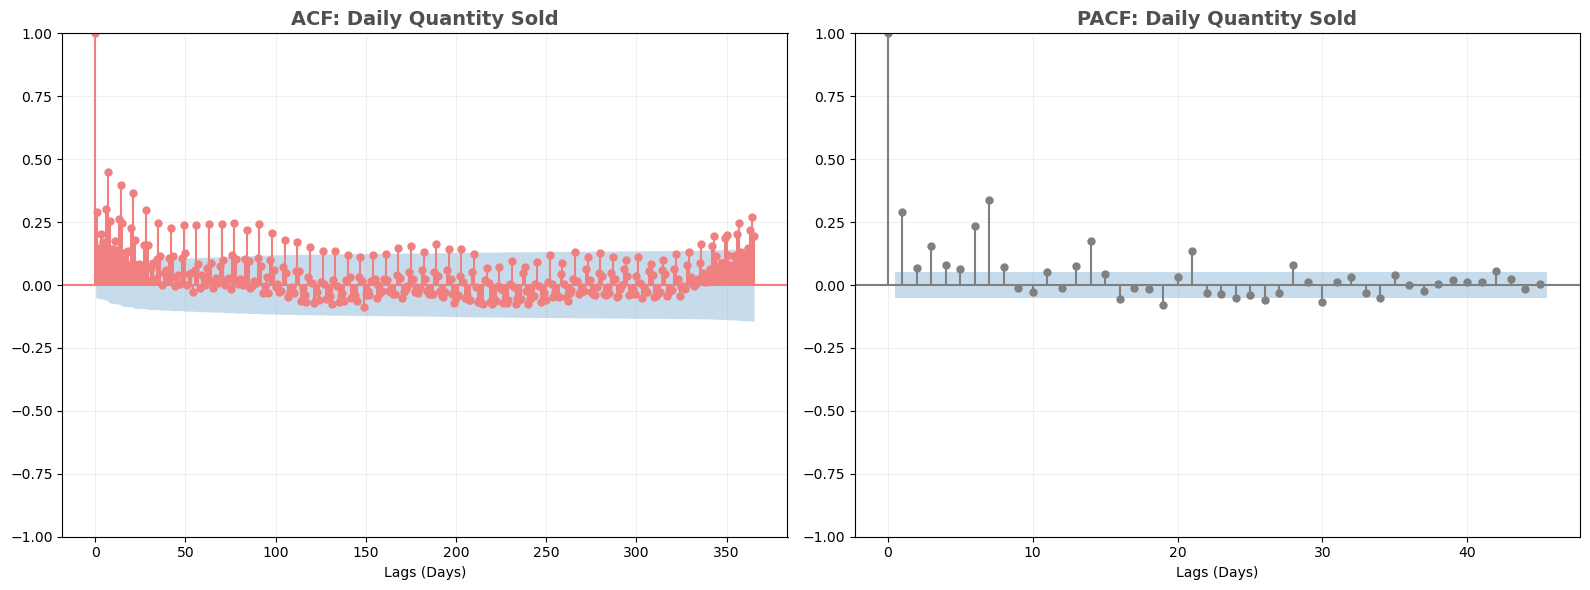

In [54]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. Resample to Daily ('D') - Ensures the index is continuous
total_daily_qty = df_complete['Quantity'].resample('D').sum()

# 2. Setup Plot (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# --- 3. Plot ACF (Daily Autocorrelation) ---
# We use 365 lags to see if there is a year-over-year daily correlation
plot_acf(total_daily_qty, lags=365, ax=axes[0], color='#F08080', vlines_kwargs={"colors": '#F08080'}) 
axes[0].set_title('ACF: Daily Quantity Sold', fontsize=14, fontweight='bold', color='#4F4F4F')
axes[0].set_xlabel('Lags (Days)')
axes[0].grid(alpha=0.2)

# --- 4. Plot PACF (Daily Partial Autocorrelation) ---
# We focus on the first 45 days to see immediate direct "momentum"
plot_pacf(total_daily_qty, lags=45, ax=axes[1], color='#808080', vlines_kwargs={"colors": '#808080'}, method='ywm') 
axes[1].set_title('PACF: Daily Quantity Sold', fontsize=14, fontweight='bold', color='#4F4F4F')
axes[1].set_xlabel('Lags (Days)')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

**adding 1/6/7 lags to quantity**


**adding 7 rolling mean/std, 365 rolling mean**

### Feature Engineering

**transforming price into its orig price (accounting for discount & leakage)**

In [70]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from pandas.tseries.holiday import USFederalHolidayCalendar

class DemandFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, window=7):
        self.window = window
        self.holidays = None

    def fit(self, X, y=None):
        cal = USFederalHolidayCalendar()
        start, end = X['Order Date'].min(), X['Order Date'].max() + pd.Timedelta(days=365)
        self.holidays = cal.holidays(start=start, end=end)
        return self

    def transform(self, X):
        X = X.copy().sort_values(['Product Subcategory', 'Order Date'])
        
        # Temporal Logic
        X['day_of_week'] = X['Order Date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['Order Date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['Order Date'].dt.month / 12)
        X['is_holiday'] = X['Order Date'].isin(self.holidays).astype(int)
        X['to_holiday'] = X['Order Date'].apply(
            lambda d: (self.holidays[self.holidays >= d].min() - d).days 
            if not self.holidays[self.holidays >= d].empty else 365
        )
        
        # Price Feature (Lagged)
        X['obs_price'] = X['Sales'] / X['Quantity'].replace(0, 1e-6)
        X['lagged_price'] = X.groupby('Product Subcategory')['obs_price']\
                             .transform(lambda x: x.shift(1).rolling(self.window, min_periods=1).median())
        X['lagged_price'] = X['lagged_price'].fillna(X['base_unit_price'])

        # Quantity Lags
        grouped_qty = X.groupby('Product Subcategory')['Quantity']
        for l in [1, 7]:
            X[f'qty_lag_{l}'] = grouped_qty.shift(l)
        X['qty_roll_mean'] = grouped_qty.transform(lambda x: x.shift(1).rolling(self.window).mean())
        
        drop_cols = ['Order Date', 'Sales', 'Profit', 'obs_price', 'base_unit_price', 'unit_cost']
        return X.drop(columns=[c for c in drop_cols if c in X.columns]).fillna(0)

class ColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column_name, categories):
        self.column_name = column_name
        self.categories = categories 
        self.le = LabelEncoder().fit(self.categories)

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        X[self.column_name] = X[self.column_name].apply(
            lambda x: x if x in self.le.classes_ else self.le.classes_[0]
        )
        X[self.column_name] = self.le.transform(X[self.column_name])
        return X

# (DemandFeatureEngineer remains as defined in previous block)

In [71]:
# --- 1. Data Prep ---
X_all = df_complete.reset_index()
y_all = X_all['Quantity']
all_subcats = X_all['Product Subcategory'].unique()

# --- 2. Define Split ---
tscv = TimeSeriesSplit(n_splits=3)
# We take the indices of the very last split for our "Final Test"
splits = list(tscv.split(X_all))
train_idx, test_idx = splits[-1] 

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

# --- 3. Prep Eval Set for Early Stopping ---
eng_eval = DemandFeatureEngineer().fit(X_train)
enc_eval = ColumnLabelEncoder('Product Subcategory', all_subcats)
X_test_transformed = enc_eval.transform(eng_eval.transform(X_test))

# --- 4. Pipeline & Search ---
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, 
                           early_stopping_rounds=50, random_state=42, n_jobs=-1)

search_pipe = Pipeline([
    ('engineer', DemandFeatureEngineer()),
    ('encoder', ColumnLabelEncoder('Product Subcategory', all_subcats)),
    ('model', xgb_reg)
])

random_search = RandomizedSearchCV(
    search_pipe, 
    param_distributions={'model__max_depth': [3, 5, 7], 'model__learning_rate': [0.01, 0.05, 0.1]}, 
    n_iter=5, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42
)

# --- 5. Fit ---
random_search.fit(
    X_train, y_train, 
    model__eval_set=[(X_test_transformed, y_test)], 
    model__verbose=False
)

# --- 6. PREDICT (Using the best estimator on the X_test) ---
y_pred = random_search.predict(X_test)

# Check shapes before math
print(f"y_test shape: {y_test.shape}, y_pred shape: {y_pred.shape}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final RMSE: {rmse:.2f} Units")

y_test shape: (7054,), y_pred shape: (7054,)
Final RMSE: 2.42 Units


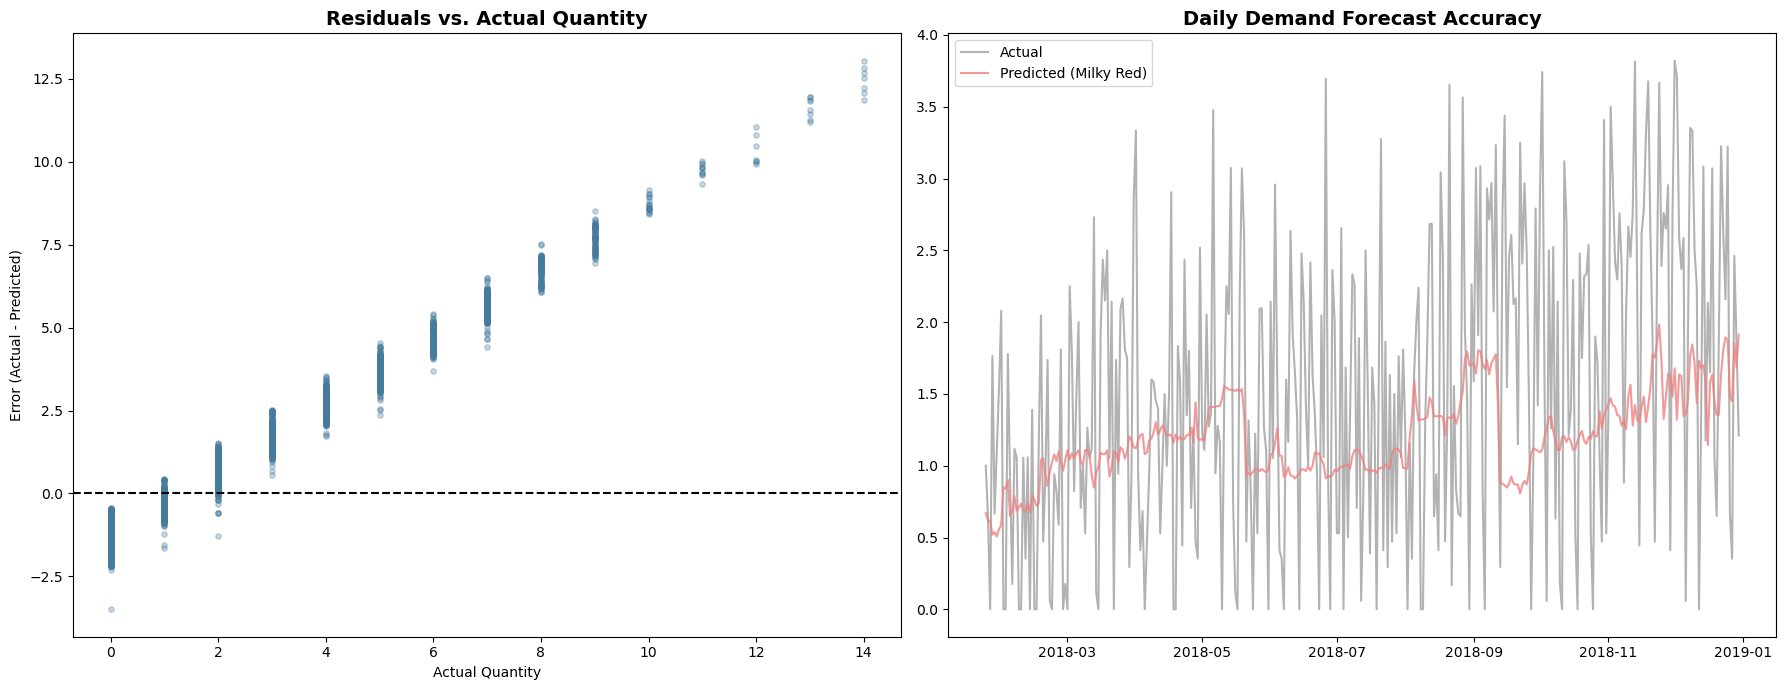

In [72]:
# 1. Calculate Residuals
test_residuals = y_test.values - y_pred # Using .values ensures alignment

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Subplot 1: Residuals vs Quantity (Checks for Bias)
ax1.scatter(y_test, test_residuals, alpha=0.3, color='#457B9D', s=15)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.set_title("Residuals vs. Actual Quantity", fontsize=14, fontweight='bold')
ax1.set_xlabel("Actual Quantity")
ax1.set_ylabel("Error (Actual - Predicted)")

# Subplot 2: Actual vs Predicted Over Time (Checks for Trend)
temp_df = pd.DataFrame({'Date': X_test['Order Date'], 'Actual': y_test, 'Pred': y_pred})
daily_data = temp_df.groupby('Date').mean()

ax2.plot(daily_data.index, daily_data['Actual'], color='#808080', alpha=0.6, label='Actual')
ax2.plot(daily_data.index, daily_data['Pred'], color='#F08080', alpha=0.8, label='Predicted (Milky Red)')
ax2.set_title("Daily Demand Forecast Accuracy", fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

### Trying Deep learning model

In [74]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Dropout, Input
from sklearn.preprocessing import StandardScaler

class DemandFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, window=7):
        self.window = window
        self.holidays = None

    def fit(self, X, y=None):
        cal = USFederalHolidayCalendar()
        start, end = X['Order Date'].min(), X['Order Date'].max() + pd.Timedelta(days=365)
        self.holidays = cal.holidays(start=start, end=end)
        return self

    def transform(self, X):
        X = X.copy().sort_values(['Product Subcategory', 'Order Date'])
        X['day_of_week'] = X['Order Date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['Order Date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['Order Date'].dt.month / 12)
        X['is_holiday'] = X['Order Date'].isin(self.holidays).astype(int)
        
        # Corrected Price Logic
        X['obs_price'] = X['Sales'] / X['Quantity'].replace(0, 1e-6)
        X['lagged_price'] = X.groupby('Product Subcategory')['obs_price']\
                             .transform(lambda x: x.shift(1).rolling(self.window, min_periods=1).median())
        # Use the column name present in your df_complete
        X['lagged_price'] = X['lagged_price'].fillna(X['base_unit_price'])

        grouped_qty = X.groupby('Product Subcategory')['Quantity']
        for l in [1, 7]:
            X[f'qty_lag_{l}'] = grouped_qty.shift(l)
        X['qty_roll_mean'] = grouped_qty.transform(lambda x: x.shift(1).rolling(self.window).mean())
        
        drop_cols = ['Order Date', 'Sales', 'Profit', 'obs_price', 'base_unit_price', 'unit_cost']
        return X.drop(columns=[c for c in drop_cols if c in X.columns]).fillna(0)

# Re-initialize the processors
eng = DemandFeatureEngineer().fit(X_train)
enc = ColumnLabelEncoder('Product Subcategory', all_subcats)

# Transform to 2D
X_train_2d = enc.transform(eng.transform(X_train))
X_test_2d = enc.transform(eng.transform(X_test))

# Scaler is vital for Neural Network Convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

In [75]:
def create_sequences(data, target, window=14):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:(i + window)])
        y.append(target.iloc[i + window])
    return np.array(X), np.array(y)

X_train_3d, y_train_3d = create_sequences(X_train_scaled, y_train)
X_test_3d, y_test_3d = create_sequences(X_test_scaled, y_test)

# --- LSTM Model ---
lstm_model = Sequential([
    Input(shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_3d, y_train_3d, epochs=15, batch_size=64, verbose=0)

# --- CNN Model ---
cnn_model = Sequential([
    Input(shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_3d, y_train_3d, epochs=15, batch_size=64, verbose=0)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy

220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step
LSTM RMSE: 2.48 | CNN RMSE: 2.49


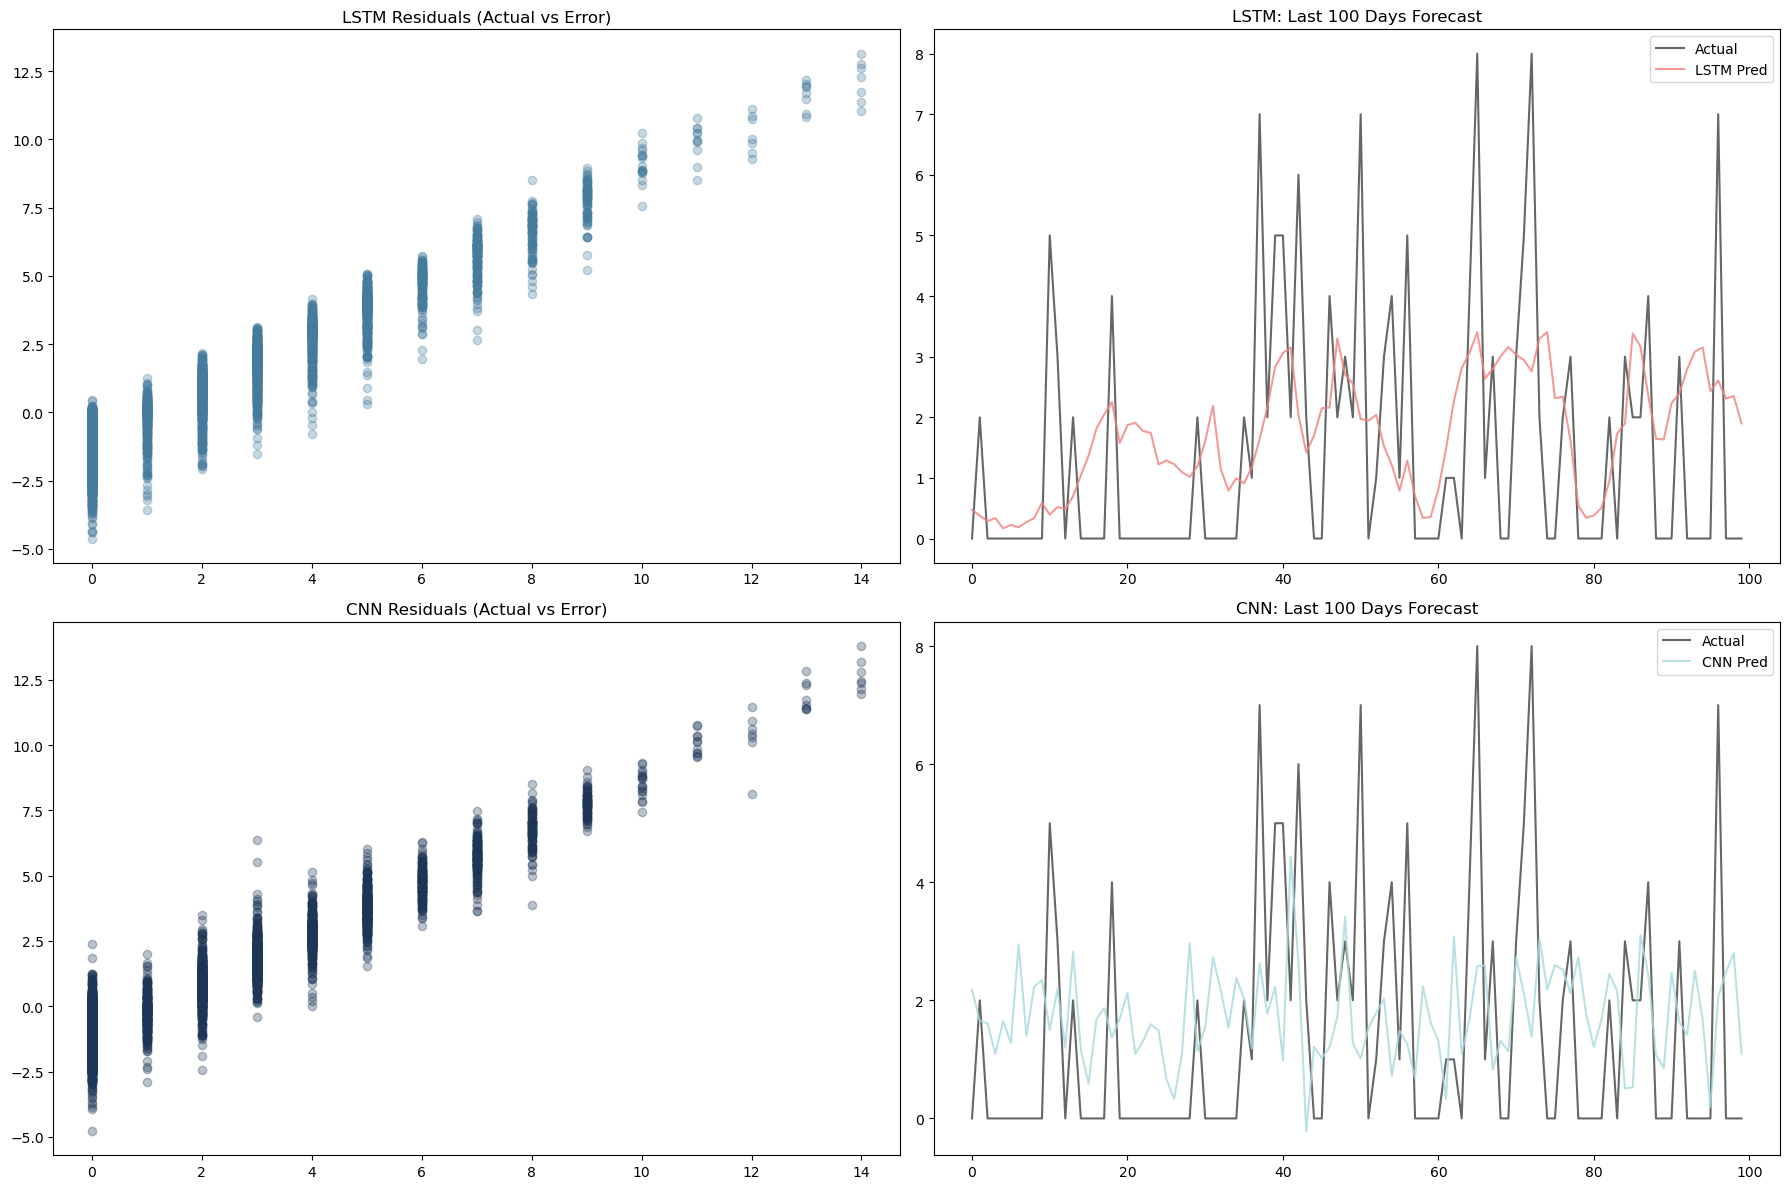

In [76]:
y_pred_lstm = lstm_model.predict(X_test_3d).flatten()
y_pred_cnn = cnn_model.predict(X_test_3d).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test_3d, y_pred_lstm))
rmse_cnn = np.sqrt(mean_squared_error(y_test_3d, y_pred_cnn))

print(f"LSTM RMSE: {rmse_lstm:.2f} | CNN RMSE: {rmse_cnn:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='white')

# LSTM Analysis
axes[0, 0].scatter(y_test_3d, (y_test_3d - y_pred_lstm), alpha=0.3, color='#457B9D')
axes[0, 0].set_title("LSTM Residuals (Actual vs Error)")
axes[0, 1].plot(y_test_3d[-100:], label='Actual', alpha=0.6, color='black')
axes[0, 1].plot(y_pred_lstm[-100:], label='LSTM Pred', alpha=0.8, color='#F08080')
axes[0, 1].set_title("LSTM: Last 100 Days Forecast")
axes[0, 1].legend()

# CNN Analysis
axes[1, 0].scatter(y_test_3d, (y_test_3d - y_pred_cnn), alpha=0.3, color='#1D3557')
axes[1, 0].set_title("CNN Residuals (Actual vs Error)")
axes[1, 1].plot(y_test_3d[-100:], label='Actual', alpha=0.6, color='black')
axes[1, 1].plot(y_pred_cnn[-100:], label='CNN Pred', alpha=0.8, color='#A8DADC')
axes[1, 1].set_title("CNN: Last 100 Days Forecast")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Using Tweedie Objective with Xgboost

In [77]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from pandas.tseries.holiday import USFederalHolidayCalendar

class DemandFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, window=7):
        self.window = window
        self.holidays = None

    def fit(self, X, y=None):
        cal = USFederalHolidayCalendar()
        start, end = X['Order Date'].min(), X['Order Date'].max() + pd.Timedelta(days=365)
        self.holidays = cal.holidays(start=start, end=end)
        return self

    def transform(self, X):
        X = X.copy().sort_values(['Product Subcategory', 'Order Date'])
        
        # Temporal Logic
        X['day_of_week'] = X['Order Date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['Order Date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['Order Date'].dt.month / 12)
        X['is_holiday'] = X['Order Date'].isin(self.holidays).astype(int)
        
        # Causal Price Feature (Lagged to avoid leakage)
        # We use epsilon 1e-6 to avoid infinity on zero-quantity days
        X['obs_price'] = X['Sales'] / X['Quantity'].replace(0, 1e-6)
        X['lagged_price'] = X.groupby('Product Subcategory')['obs_price']\
                             .transform(lambda x: x.shift(1).rolling(self.window, min_periods=1).median())
        
        # Fallback to the catalog price from your df_complete
        X['lagged_price'] = X['lagged_price'].fillna(X['base_unit_price'])

        # Quantity Momentum
        grouped_qty = X.groupby('Product Subcategory')['Quantity']
        for l in [1, 7]:
            X[f'qty_lag_{l}'] = grouped_qty.shift(l)
        X['qty_roll_mean'] = grouped_qty.transform(lambda x: x.shift(1).rolling(self.window).mean())
        
        # Drop raw target-linked columns
        drop_cols = ['Order Date', 'Sales', 'Profit', 'obs_price', 'base_unit_price', 'unit_cost']
        return X.drop(columns=[c for c in drop_cols if c in X.columns]).fillna(0)

class ColumnLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column_name, categories):
        self.column_name = column_name
        self.categories = categories # Saved for sklearn cloning
        self.le = LabelEncoder().fit(self.categories)

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        X[self.column_name] = X[self.column_name].apply(
            lambda x: x if x in self.le.classes_ else self.le.classes_[0]
        )
        X[self.column_name] = self.le.transform(X[self.column_name])
        return X

In [78]:
# --- Setup ---
X_all = df_complete.reset_index()
y_all = X_all['Quantity']
all_subcats = X_all['Product Subcategory'].unique()

tscv = TimeSeriesSplit(n_splits=3)
splits = list(tscv.split(X_all))
train_idx, test_idx = splits[-1] # Focus on the most recent holdout split

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

# --- Manual Transform for Eval Set ---
eng_eval = DemandFeatureEngineer().fit(X_train)
enc_eval = ColumnLabelEncoder('Product Subcategory', all_subcats)
X_test_transformed = enc_eval.transform(eng_eval.transform(X_test))

# --- Model Definition (Tweedie) ---
# Tweedie is robust against zero-inflated data
xgb_tweedie = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5, 
    n_estimators=1000,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

prod_pipe = Pipeline([
    ('engineer', DemandFeatureEngineer()),
    ('encoder', ColumnLabelEncoder('Product Subcategory', all_subcats)),
    ('model', xgb_tweedie)
])

# --- Search & Fit ---
params = {
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 0.9]
}

random_search = RandomizedSearchCV(
    prod_pipe, 
    param_distributions=params, 
    n_iter=5, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42
)

random_search.fit(
    X_train, y_train, 
    model__eval_set=[(X_test_transformed, y_test)], 
    model__verbose=False
)

# --- Predict ---
y_pred = random_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Tweedie Model RMSE: {rmse:.2f} Units")

Tweedie Model RMSE: 2.44 Units


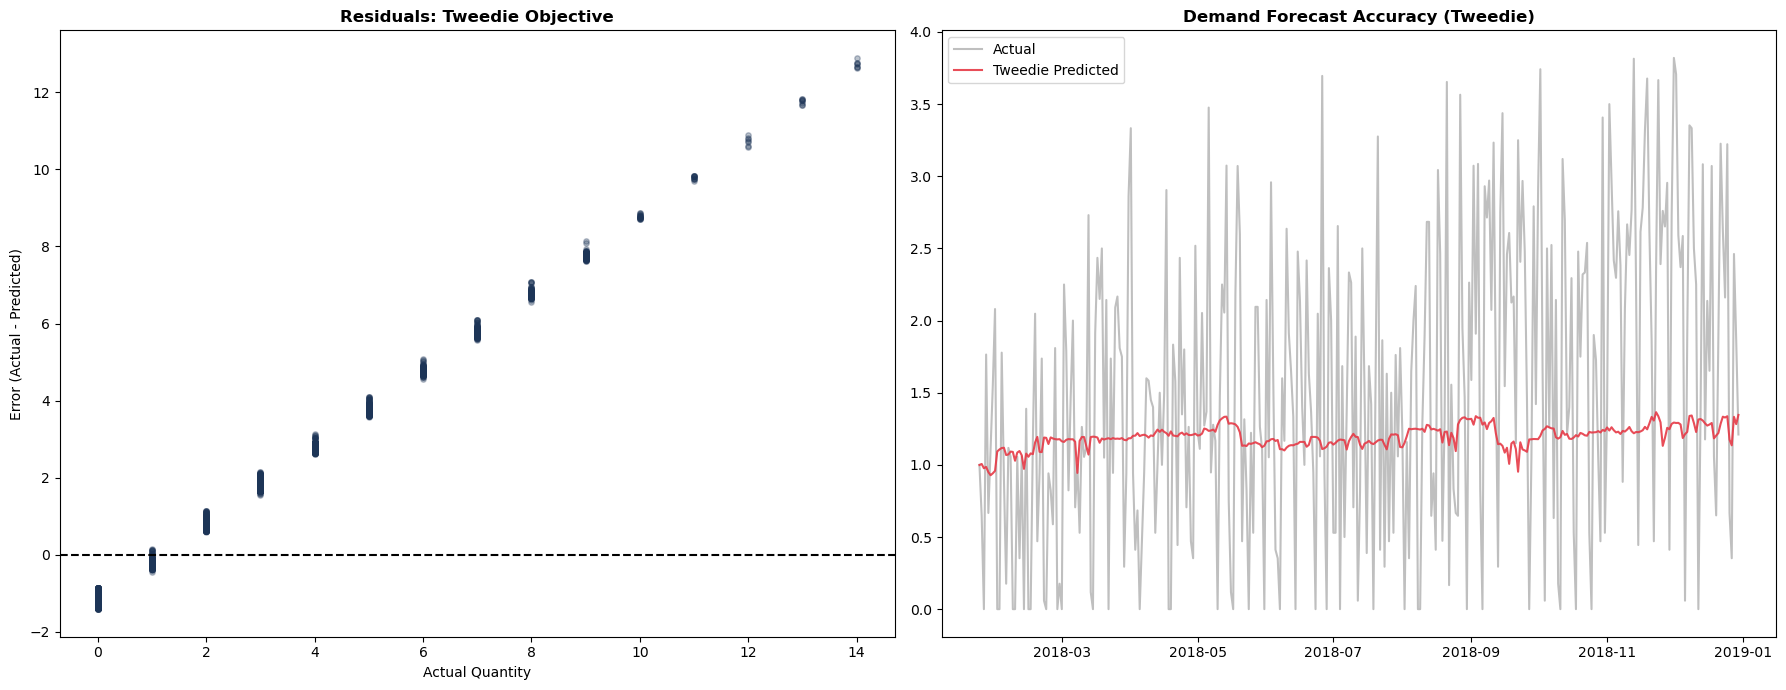

In [79]:
# Align y_test values with predictions
test_residuals = y_test.values - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Subplot 1: Residual Scatter
ax1.scatter(y_test, test_residuals, alpha=0.3, color='#1D3557', s=15)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title("Residuals: Tweedie Objective", fontweight='bold')
ax1.set_xlabel("Actual Quantity")
ax1.set_ylabel("Error (Actual - Predicted)")

# Subplot 2: Temporal Accuracy (Aggregated by Date)
viz_df = pd.DataFrame({'Date': X_test['Order Date'], 'Actual': y_test, 'Pred': y_pred})
daily_viz = viz_df.groupby('Date').mean()

ax2.plot(daily_viz.index, daily_viz['Actual'], color='#808080', alpha=0.5, label='Actual')
ax2.plot(daily_viz.index, daily_viz['Pred'], color='#E63946', alpha=0.9, label='Tweedie Predicted')
ax2.set_title("Demand Forecast Accuracy (Tweedie)", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

**Hurdle demand model**

In [90]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier, XGBRegressor

class HurdleDemandModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier_params=None, regressor_params=None):
        self.classifier_params = classifier_params or {}
        self.regressor_params = regressor_params or {}
        # We don't initialize the models in __init__ for better cloning support
        
    def fit(self, X, y):
        # 1. Initialize models inside fit
        self.clf_ = XGBClassifier(**self.classifier_params)
        self.reg_ = XGBRegressor(**self.regressor_params)
        
        # 2. Train Classifier (The Hurdle)
        y_binary = (y > 0).astype(int)
        self.clf_.fit(X, y_binary)
        
        # 3. Train Regressor (The Intensity)
        mask = y > 0
        if mask.any():
            self.reg_.fit(X[mask], y[mask])
        else:
            # Fallback if no sales exist in a slice
            self.reg_.fit(X, y)
            
        # 4. Mark as fitted by creating an attribute ending in underscore
        self.is_fitted_ = True
        return self

    def predict(self, X):
        # Check if fit was called
        check_is_fitted(self, 'is_fitted_')
        
        # Prob(Sale) * Expected Quantity
        prob_sale = self.clf_.predict_proba(X)[:, 1]
        pred_qty = self.reg_.predict(X)
        
        return prob_sale * np.maximum(0, pred_qty)

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\174809319.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.reg_.fit(X[mask], y[mask])


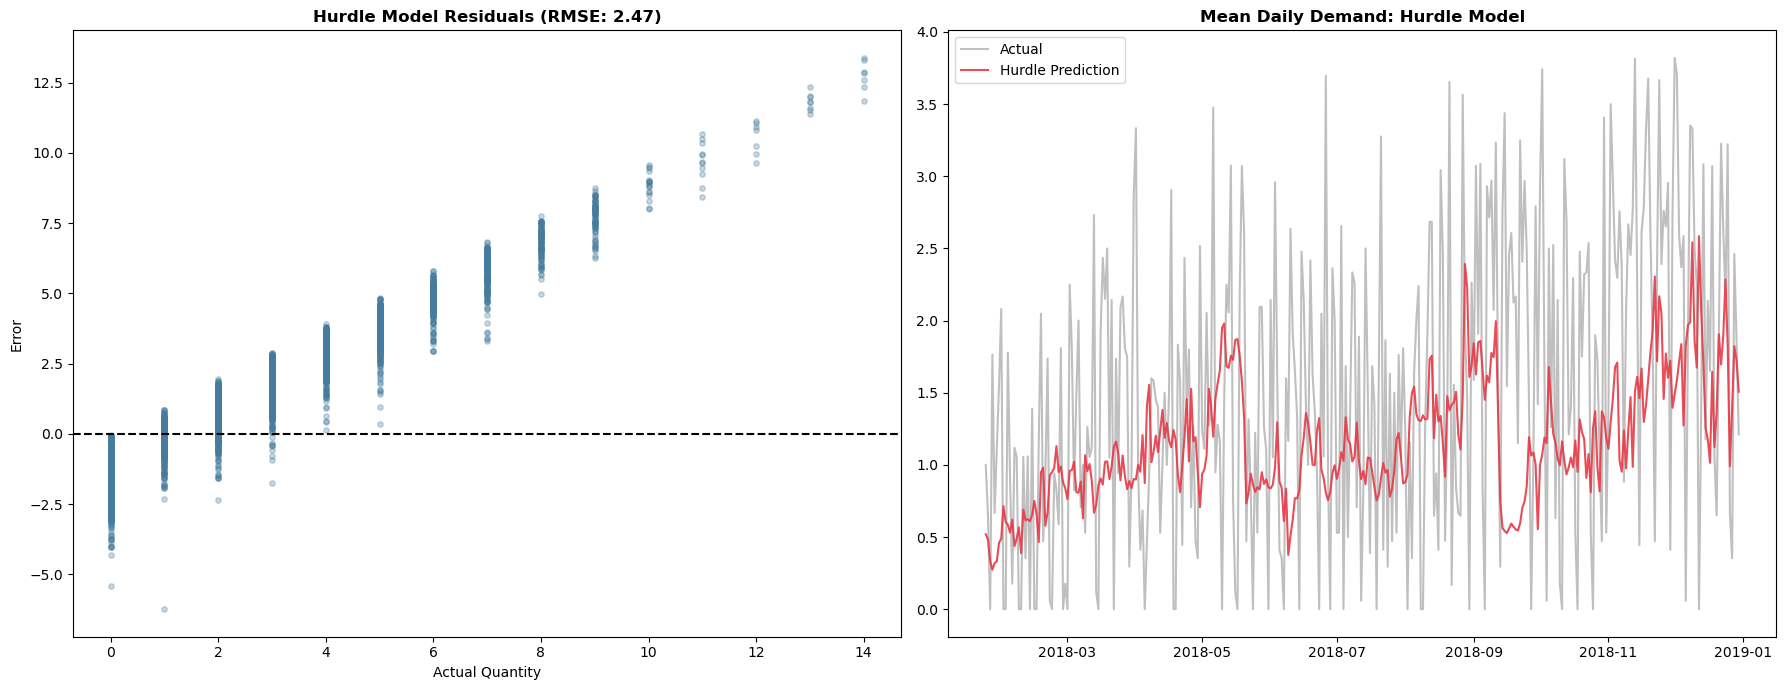

In [100]:
# 1. Pipeline Definition
hurdle_pipe = Pipeline([
    ('engineer', DemandFeatureEngineer()),
    ('encoder', ColumnLabelEncoder('Product Subcategory', all_subcats)),
    ('model', HurdleDemandModel(
        classifier_params={'n_estimators': 100, 'max_depth': 4, 'random_state': 42},
        regressor_params={'objective': 'reg:tweedie', 'tweedie_variance_power': 1.5, 'n_estimators': 100}
    ))
])

# 2. Fit and Predict
hurdle_pipe.fit(X_train, y_train)
y_pred_hurdle = hurdle_pipe.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_hurdle))

# 3. Residual and Time Plots
test_residuals = y_test.values - y_pred_hurdle
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')

# Subplot 1: Residuals
ax1.scatter(y_test, test_residuals, alpha=0.3, color='#457B9D', s=15)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(f"Hurdle Model Residuals (RMSE: {rmse:.2f})", fontweight='bold')
ax1.set_xlabel("Actual Quantity")
ax1.set_ylabel("Error")

# Subplot 2: Time Series Comparison
viz_df = pd.DataFrame({'Date': X_test['Order Date'], 'Actual': y_test, 'Pred': y_pred_hurdle})
daily_viz = viz_df.groupby('Date').mean()

ax2.plot(daily_viz.index, daily_viz['Actual'], color='#808080', alpha=0.5, label='Actual')
ax2.plot(daily_viz.index, daily_viz['Pred'], color='#E63946', alpha=0.9, label='Hurdle Prediction')
ax2.set_title("Mean Daily Demand: Hurdle Model", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

### Trying Class balancing

In [103]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier, XGBRegressor

# --- APPROACH 1: LOG TRANSFORMATION ---
class LogHurdleModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier_params=None, regressor_params=None):
        self.classifier_params = classifier_params or {}
        self.regressor_params = regressor_params or {}

    def fit(self, X, y):
        self.clf_ = XGBClassifier(**self.classifier_params).fit(X, (y > 0).astype(int))
        mask = y > 0
        # Target is log-transformed: log(1 + y)
        self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], np.log1p(y[mask]))
        self.is_fitted_ = True
        return self

    def predict(self, X):
        prob = self.clf_.predict_proba(X)[:, 1]
        # Invert the log: exp(y) - 1
        pred_log = self.reg_.predict(X)
        return prob * np.expm1(pred_log)

# --- APPROACH 2: CUSTOM LOSS WEIGHTS ---
class WeightedHurdleModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier_params=None, regressor_params=None):
        self.classifier_params = classifier_params or {}
        self.regressor_params = regressor_params or {}

    def fit(self, X, y):
        self.clf_ = XGBClassifier(**self.classifier_params).fit(X, (y > 0).astype(int))
        mask = y > 0
        # Weights increase with quantity magnitude
        weights = 1 + np.log1p(y[mask]) 
        self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], y[mask], sample_weight=weights)
        self.is_fitted_ = True
        return self

    def predict(self, X):
        return self.clf_.predict_proba(X)[:, 1] * self.reg_.predict(X)

# --- APPROACH 3: STRATEGIC BINNING (Multi-Stage) ---
class BinnedHurdleModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier_params=None, regressor_params=None):
        self.classifier_params = classifier_params or {}
        self.regressor_params = regressor_params or {}

    def fit(self, X, y):
        # Stage 1: Did it sell?
        self.clf_ = XGBClassifier(**self.classifier_params).fit(X, (y > 0).astype(int))
        # Stage 2: Is it a 'Big' sale? (e.g., > 5 units)
        mask = y > 0
        self.is_big_clf_ = XGBClassifier(**self.classifier_params).fit(X[mask], (y[mask] > 5).astype(int))
        # Stage 3: Direct Regression
        self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], y[mask])
        self.is_fitted_ = True
        return self

    def predict(self, X):
        prob_any = self.clf_.predict_proba(X)[:, 1]
        prob_big = self.is_big_clf_.predict_proba(X)[:, 1]
        raw_qty = self.reg_.predict(X)
        # Weighting by both 'Sale Prob' and 'Volume Prob'
        return prob_any * (raw_qty + (prob_big * 5)) # Boosts the spikes


In [104]:
# Shared Hyperparameters
c_params = {'n_estimators': 100, 'max_depth': 4, 'random_state': 42, 'scale_pos_weight': 1.8}
r_params = {'objective': 'reg:tweedie', 'tweedie_variance_power': 1.1, 'n_estimators': 100}

models = {
    "Log-Transform": LogHurdleModel(c_params, r_params),
    "Loss-Weighted": WeightedHurdleModel(c_params, r_params),
    "Binned-Classifier": BinnedHurdleModel(c_params, r_params)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('eng', DemandFeatureEngineer(window=14)),
        ('enc', ColumnLabelEncoder('Product Subcategory', all_subcats)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    results[name] = pipe.predict(X_test)

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\1651778358.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], np.log1p(y[mask]))
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\1651778358.py:36: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], y[mask], sample_weight=weights)
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\1651778358.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.is_big_clf_ = XGBClassifier(**self.classifier_params).fit(X[mask], (y[mask] > 5).astype(int))
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\1651778358.py:56: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], y[mask])


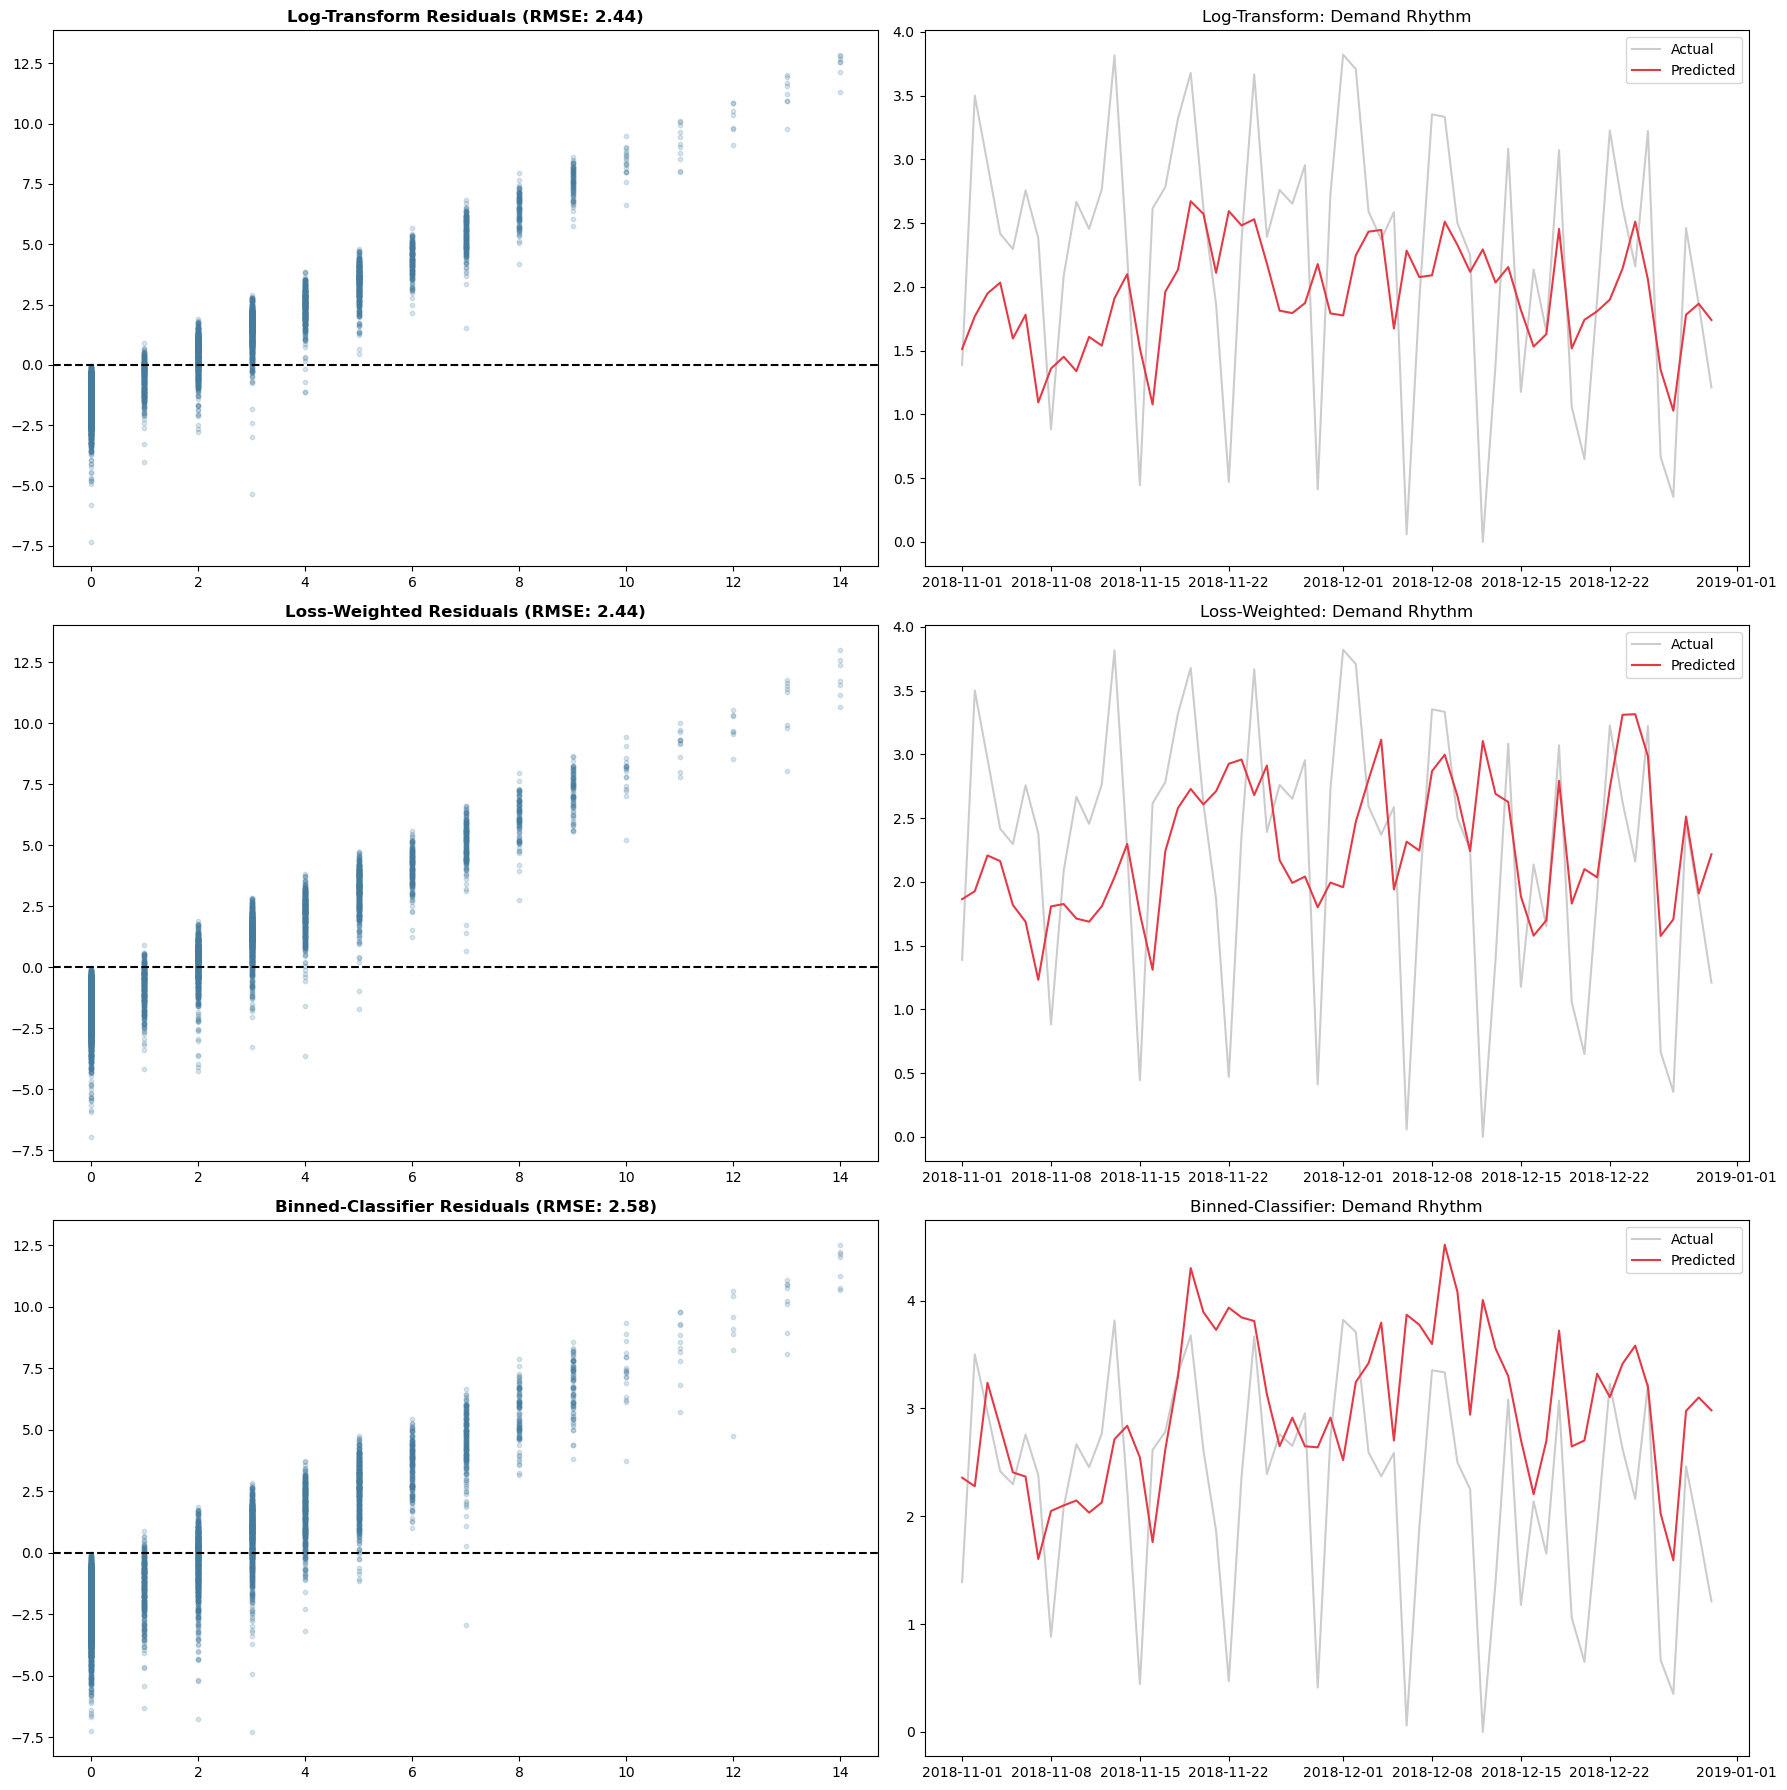

In [105]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18), facecolor='white')

for i, (name, y_pred) in enumerate(results.items()):
    residuals = y_test.values - y_pred
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Subplot 1: Residuals vs Quantity
    axes[i, 0].scatter(y_test, residuals, alpha=0.2, color='#457B9D', s=10)
    axes[i, 0].axhline(0, color='black', linestyle='--')
    axes[i, 0].set_title(f"{name} Residuals (RMSE: {rmse:.2f})", fontweight='bold')
    
    # Subplot 2: Time Series Snapshot (Last 60 Days)
    viz_df = pd.DataFrame({'Date': X_test['Order Date'], 'Actual': y_test, 'Pred': y_pred})
    daily = viz_df.groupby('Date').mean().tail(60)
    
    axes[i, 1].plot(daily.index, daily['Actual'], color='#808080', alpha=0.4, label='Actual')
    axes[i, 1].plot(daily.index, daily['Pred'], color='#E63946', label='Predicted')
    axes[i, 1].set_title(f"{name}: Demand Rhythm")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

**Choosing the log-transformation approach**

In [109]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from pandas.tseries.holiday import USFederalHolidayCalendar

class UltimateFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, window=14):
        self.window = window
        self.holidays = None

    def fit(self, X, y=None):
        cal = USFederalHolidayCalendar()
        start, end = X['Order Date'].min(), X['Order Date'].max() + pd.Timedelta(days=365)
        self.holidays = cal.holidays(start=start, end=end)
        return self

    def transform(self, X):
        X = X.copy().sort_values(['Product Subcategory', 'Order Date'])
        
        # --- 1. Basic Temporal ---
        X['day_of_month'] = X['Order Date'].dt.day
        X['is_month_start'] = (X['day_of_month'] <= 3).astype(int)
        X['is_month_end'] = (X['day_of_month'] >= 28).astype(int)
        
        # --- 2. Payday Logic (1st and 15th Surges) ---
        X['dist_to_payday'] = X['day_of_month'].apply(lambda d: min(abs(d-1), abs(d-15), abs(d-30)))
        
        # --- 3. Seasonal Logic (Back-to-School: Aug/Sept) ---
        # Affects: 'Binders', 'Paper', 'Art', 'Supplies'
        bts_months = [8, 9]
        bts_categories = ['Binders', 'Paper', 'Art', 'Supplies', 'Labels']
        X['is_bts_season'] = X['Order Date'].dt.month.isin(bts_months).astype(int)
        X['bts_impact'] = X.apply(lambda row: 1 if (row['is_bts_season'] and row['Product Subcategory'] in bts_categories) else 0, axis=1)

        # --- 4. Office Refresh Logic (Jan/Feb) ---
        # Affects: 'Chairs', 'Tables', 'Furnishings', 'Machines'
        office_cats = ['Chairs', 'Tables', 'Furnishings', 'Machines', 'Bookcases']
        X['is_office_refresh'] = X['Order Date'].dt.month.isin([1, 2]).astype(int)
        X['office_impact'] = X.apply(lambda row: 1 if (row['is_office_refresh'] and row['Product Subcategory'] in office_cats) else 0, axis=1)

        # --- 5. Holiday Proximity ---
        X['is_holiday'] = X['Order Date'].isin(self.holidays).astype(int)
        
        # --- 6. Traditional Lag & Price Features ---
        X['obs_price'] = X['Sales'] / X['Quantity'].replace(0, 1e-6)
        X['lagged_price'] = X.groupby('Product Subcategory')['obs_price']\
                             .transform(lambda x: x.shift(1).rolling(self.window, min_periods=1).median())
        X['lagged_price'] = X['lagged_price'].fillna(X['base_unit_price'])

        grouped_qty = X.groupby('Product Subcategory')['Quantity']
        for l in [1, 7, 14]:
            X[f'qty_lag_{l}'] = grouped_qty.shift(l)
        X['qty_roll_mean'] = grouped_qty.transform(lambda x: x.shift(1).rolling(self.window).mean())
        
        drop_cols = ['Order Date', 'Sales', 'Profit', 'obs_price', 'base_unit_price', 'unit_cost', 'is_bts_season', 'is_office_refresh']
        return X.drop(columns=[c for c in drop_cols if c in X.columns]).fillna(0)

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

class LogHurdleModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier_params=None, regressor_params=None):
        self.classifier_params = classifier_params or {}
        self.regressor_params = regressor_params or {}
        
    def fit(self, X, y):
        # Stage 1: Classifier
        self.clf_ = XGBClassifier(**self.classifier_params).fit(X, (y > 0).astype(int))
        # Stage 2: Log-Regressor (only on non-zeros)
        mask = y > 0
        self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], np.log1p(y[mask]))
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        prob = self.clf_.predict_proba(X)[:, 1]
        pred_log = self.reg_.predict(X)
        return prob * np.expm1(pred_log)

# Setup Hyperparams
c_params = {'n_estimators': 200, 'max_depth': 5, 'scale_pos_weight': 1.8, 'random_state': 42}
r_params = {'objective': 'reg:tweedie', 'tweedie_variance_power': 1.1, 'n_estimators': 200, 'learning_rate': 0.05}

# Build Pipeline
final_pipe = Pipeline([
    ('engineer', UltimateFeatureEngineer(window=14)),
    ('encoder', ColumnLabelEncoder('Product Subcategory', all_subcats)),
    ('model', LogHurdleModel(c_params, r_params))
])

# Training
final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17140\2279176678.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.reg_ = XGBRegressor(**self.regressor_params).fit(X[mask], np.log1p(y[mask]))


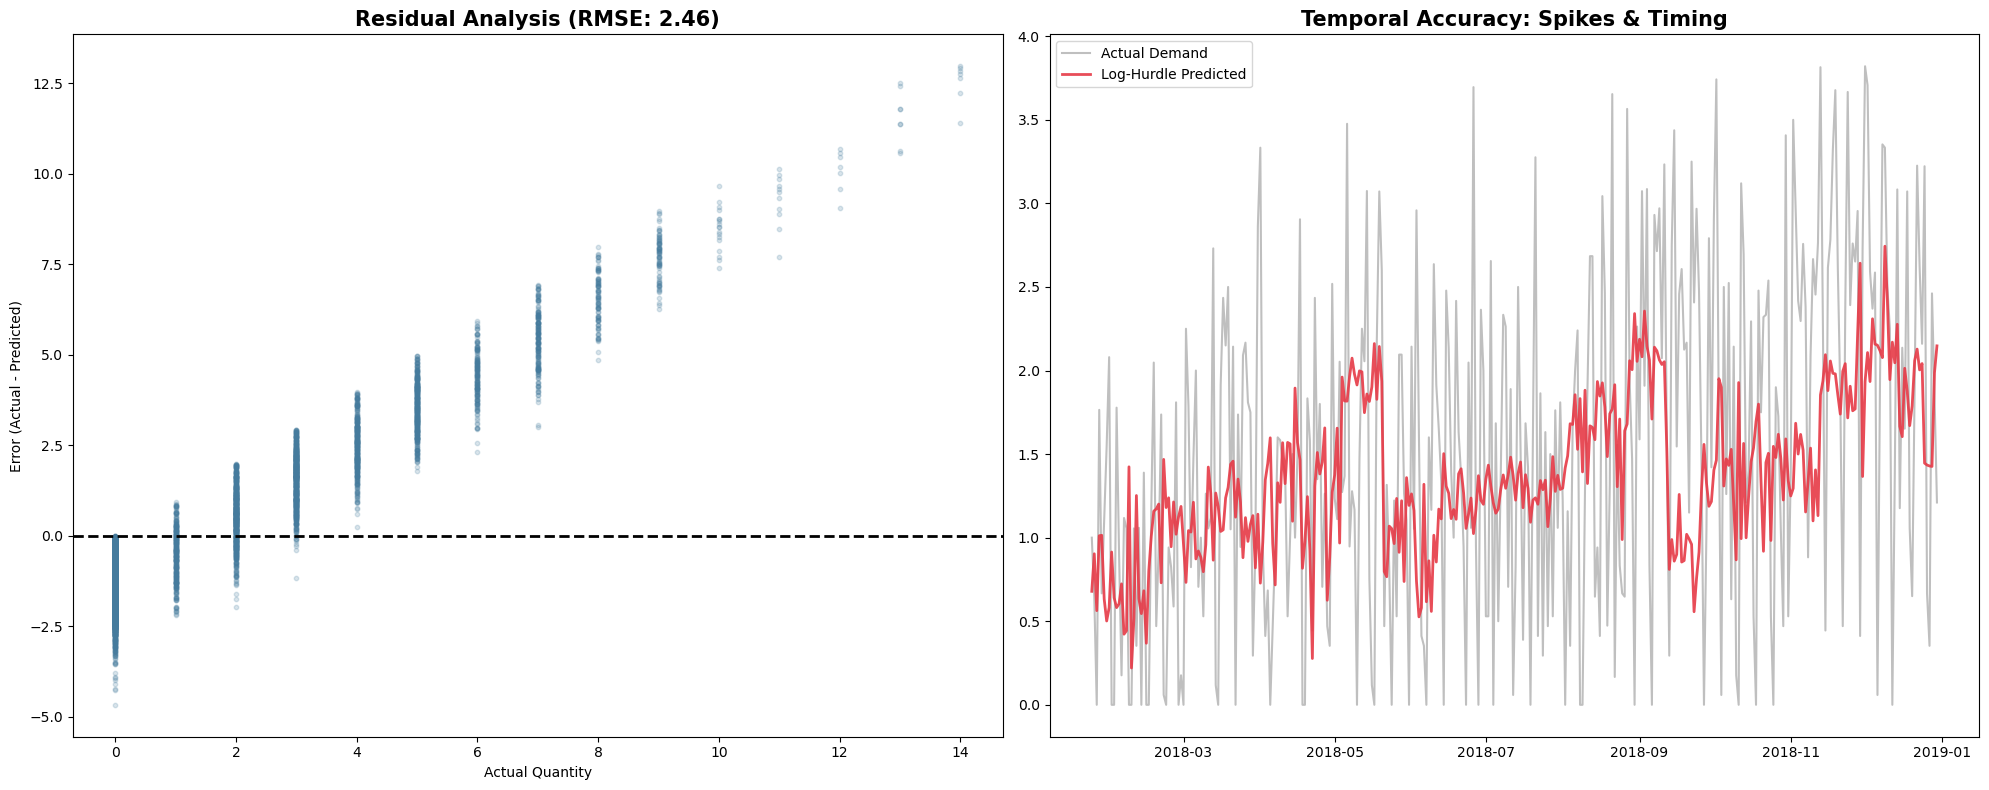

In [111]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
residuals = y_test.values - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')

# Plot 1: Residuals vs Quantity (Log-Space stability check)
ax1.scatter(y_test, residuals, alpha=0.2, color='#457B9D', s=10)
ax1.axhline(0, color='black', linestyle='--', linewidth=2)
ax1.set_title(f"Residual Analysis (RMSE: {rmse:.2f})", fontsize=15, fontweight='bold')
ax1.set_xlabel("Actual Quantity")
ax1.set_ylabel("Error (Actual - Predicted)")

# Plot 2: Demand Rhythm (Aggregated Mean)
viz_df = pd.DataFrame({'Date': X_test['Order Date'], 'Actual': y_test, 'Pred': y_pred})
daily = viz_df.groupby('Date').mean()

ax2.plot(daily.index, daily['Actual'], color='#808080', alpha=0.5, label='Actual Demand', linewidth=1.5)
ax2.plot(daily.index, daily['Pred'], color='#E63946', alpha=0.9, label='Log-Hurdle Predicted', linewidth=2)
ax2.set_title("Temporal Accuracy: Spikes & Timing", fontsize=15, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

### Business Questions

**StockOut Flag**

In [117]:
# --- STEP 1: PREPARE FUTURE DATA (Q1 2019) ---
future_dates = pd.date_range(start='2019-01-01', end='2019-03-31', freq='D')
subcats = all_subcats 

future_df = pd.DataFrame([(d, s) for d in future_dates for s in subcats], 
                         columns=['Order Date', 'Product Subcategory'])

# Patch ALL missing columns required by the Pipeline's Feature Engineer & XGBoost
future_df['Sales'] = 0.0
future_df['Quantity'] = 0.0
future_df['Profit'] = 0.0
future_df['Discount'] = 0.0  # <--- Added this to fix your specific error

# Merge catalog data for 'base_unit_price' fallback
catalog = df_complete[['Product Subcategory', 'base_unit_price']].drop_duplicates()
future_df = future_df.merge(catalog, on='Product Subcategory', how='left')

# --- STEP 2: GENERATE PREDICTIONS ---
# The pipeline will now find 'Discount' and be happy.
q1_preds = final_pipe.predict(future_df)
future_df['Predicted_Qty'] = q1_preds

# --- STEP 3: AGGREGATE & COMPARE ---
if not isinstance(df_complete.index, pd.DatetimeIndex):
    df_complete.index = pd.to_datetime(df_complete.index)

q4_actuals = df_complete[df_complete.index >= '2018-10-01'].groupby('Product Subcategory')['Quantity'].sum()
q1_forecast = future_df.groupby('Product Subcategory')['Predicted_Qty'].sum()

# Build Summary
summary = pd.DataFrame({
    'Previous (Q4 2018)': q4_actuals,
    'Forecast (Q1 2019)': q1_forecast
}).fillna(0)

summary['Growth %'] = ((summary['Forecast (Q1 2019)'] - summary['Previous (Q4 2018)']) / 
                       summary['Previous (Q4 2018)'].replace(0, 1) * 100)

def classify_stock(row):
    if row['Growth %'] > 10: return 'Risk: Stockout'
    elif row['Growth %'] < -10: return 'Risk: Overstock'
    else: return 'Stable'

summary['Recommendation'] = summary.apply(classify_stock, axis=1)

# --- STEP 4: EXECUTIVE DISPLAY ---
def style_inventory(df):
    return df.sort_values('Growth %', ascending=False).style.apply(lambda x: [
        'background-color: #e8f5e9; color: #2e7d32' if v == 'Stable' else 
        'background-color: #fce4e4; color: #c62828' if v == 'Risk: Stockout' else 
        'background-color: #fffde7; color: #f9a825' if v == 'Risk: Overstock' else '' 
        for v in x], subset=['Recommendation'])\
    .format({
        'Previous (Q4 2018)': '{:,.0f} Units', 
        'Forecast (Q1 2019)': '{:,.0f} Units', 
        'Growth %': '{:+.1f}%'
    })\
    .set_caption("<b>Strategic Stocking Report: Q1 2019 Planning</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('background-color', '#1D3557'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '10px'), ('text-align', 'center')]}
    ])

executive_report = style_inventory(summary)
executive_report

,Previous (Q4 2018),Forecast (Q1 2019),Growth %,Recommendation
Product Subcategory,,,,
Copiers,25 Units,130 Units,+421.5%,Risk: Stockout
Supplies,53 Units,129 Units,+143.8%,Risk: Stockout
Machines,59 Units,129 Units,+119.0%,Risk: Stockout
Envelopes,84 Units,130 Units,+54.5%,Risk: Stockout
Bookcases,93 Units,128 Units,+37.1%,Risk: Stockout
Fasteners,103 Units,128 Units,+24.7%,Risk: Stockout
Labels,137 Units,127 Units,-7.1%,Stable
Tables,203 Units,131 Units,-35.6%,Risk: Overstock
Appliances,239 Units,128 Units,-46.6%,Risk: Overstock


In [120]:
# 1. Map Drivers to Specific Dates/Conditions
def identify_spike_reason(row):
    # Check for US Federal Holidays in 2019
    if row['Order Date'] == pd.Timestamp('2019-01-01'): return "New Year's Day (Store Re-stocking)"
    if row['Order Date'] == pd.Timestamp('2019-01-21'): return "MLK Day (Long Weekend Shopping)"
    if row['Order Date'] == pd.Timestamp('2019-02-14'): return "Valentine's Day (Gift & Art Surge)"
    if row['Order Date'] == pd.Timestamp('2019-02-18'): return "Presidents' Day (Large Item Sales)"
    
    # Check for Payday Logic (1st and 15th)
    if row['Order Date'].day in [1, 2, 15, 16]: return "Payday Cycle (High Liquidity)"
    
    # Check for Month-End/Start
    if row['Order Date'].day >= 28: return "Corporate Month-End Replenishment"
    
    # Default to Weekend Traffic
    if row['Day_of_Week'] in ['Saturday', 'Sunday']: return "Natural Weekend Foot Traffic"
    
    return "Baseline Replacement Cycle"

# 2. Prepare the Data
daily_store_pred['Day_of_Week'] = daily_store_pred['Order Date'].dt.day_name()
daily_store_pred['Primary Spike Driver'] = daily_store_pred.apply(identify_spike_reason, axis=1)

# 3. Compare to 2018 (Store-wide Daily Average)
avg_daily_2018 = q1_2018_actuals['Quantity'].mean()
peak_days_final = daily_store_pred.nlargest(10, 'Predicted_Qty').sort_values('Order Date')

# 4. Executive Display Styling
def style_surge_report(df):
    return df.style.apply(lambda x: [
        'background-color: #fce4e4; color: #c62828; font-weight: bold;' if v > avg_daily_2018 * 1.2 else 
        'background-color: #e8f5e9; color: #2e7d32;' for v in x], subset=['Predicted_Qty'])\
    .format({'Predicted_Qty': '{:.0f} Units'})\
    .set_caption("<b>Labor Demand Forecast: Staffing Surge Drivers (Q1 2019)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1D3557'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '12px'), ('text-align', 'left')]}
    ])

# Render Table
report_cols = ['Order Date', 'Day_of_Week', 'Predicted_Qty', 'Primary Spike Driver']
style_surge_report(peak_days_final[report_cols])

,Order Date,Day_of_Week,Predicted_Qty,Primary Spike Driver
48,2019-02-18 00:00:00,Monday,32 Units,Presidents' Day (Large Item Sales)
50,2019-02-20 00:00:00,Wednesday,32 Units,Baseline Replacement Cycle
51,2019-02-21 00:00:00,Thursday,35 Units,Baseline Replacement Cycle
52,2019-02-22 00:00:00,Friday,34 Units,Baseline Replacement Cycle
53,2019-02-23 00:00:00,Saturday,39 Units,Natural Weekend Foot Traffic
54,2019-02-24 00:00:00,Sunday,36 Units,Natural Weekend Foot Traffic
55,2019-02-25 00:00:00,Monday,38 Units,Baseline Replacement Cycle
56,2019-02-26 00:00:00,Tuesday,37 Units,Baseline Replacement Cycle
57,2019-02-27 00:00:00,Wednesday,36 Units,Baseline Replacement Cycle
81,2019-03-23 00:00:00,Saturday,32 Units,Natural Weekend Foot Traffic


In [121]:
# 1. Calculate Historical Elasticity & Margins
stats = df_complete.groupby('Product Subcategory').agg({
    'Quantity': 'sum',
    'Profit': 'sum',
    'Sales': 'sum',
    'Discount': 'mean'
}).reset_index()

# Calculate Profit Margin %
stats['Margin %'] = (stats['Profit'] / stats['Sales']) * 100

# Calculate Correlation between Discount and Quantity (Proxy for Elasticity)
elasticity = []
for cat in all_subcats:
    subset = df_complete[df_complete['Product Subcategory'] == cat]
    # Correlation of 1 means discount perfectly drives volume
    corr = subset['Discount'].corr(subset['Quantity'])
    elasticity.append(corr if not np.isnan(corr) else 0)

stats['Elasticity'] = elasticity

# 2. Recommendation Logic
def recommend_discount(row):
    if row['Elasticity'] > 0.3 and row['Margin %'] > 20:
        return 'Promote: High Impact'
    elif row['Elasticity'] > 0.1 and row['Margin %'] > 10:
        return 'Promote: Safe'
    elif row['Margin %'] < 5:
        return 'Avoid: Margin Risk'
    else:
        return 'Hold: Low Elasticity'

stats['Action'] = stats.apply(recommend_discount, axis=1)

# 3. Executive Styling
def style_recommender(df):
    return df.sort_values('Elasticity', ascending=False).style.apply(lambda x: [
        'background-color: #fce4e4; color: #c62828' if v == 'Avoid: Margin Risk' else 
        'background-color: #e8f5e9; color: #2e7d32' if v == 'Promote: High Impact' else
        'background-color: #e3f2fd; color: #1565c0' if v == 'Promote: Safe' else
        'background-color: #fffde7; color: #f9a825' for v in x], subset=['Action'])\
    .format({'Margin %': '{:.1f}%', 'Elasticity': '{:.2f}'})\
    .set_caption("<b>Strategic Discount Recommender System</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1D3557'), ('color', 'white')]}
    ])

# Render Table
recommendation_table = style_recommender(stats[['Product Subcategory', 'Margin %', 'Elasticity', 'Action']])
recommendation_table

,Product Subcategory,Margin %,Elasticity,Action
6,Copiers,37.2%,0.66,Promote: High Impact
4,Bookcases,-3.0%,0.64,Avoid: Margin Risk
16,Tables,-8.6%,0.63,Avoid: Margin Risk
5,Chairs,8.1%,0.61,Hold: Low Elasticity
11,Machines,1.8%,0.60,Avoid: Margin Risk
8,Fasteners,31.4%,0.58,Promote: High Impact
13,Phones,13.5%,0.52,Promote: Safe
15,Supplies,-2.5%,0.51,Avoid: Margin Risk
7,Envelopes,42.3%,0.50,Promote: High Impact
10,Labels,44.4%,0.41,Promote: High Impact


In [122]:
# 1. Identify High-Elasticity / High-Margin Items
high_impact_cats = stats[stats['Action'] == 'Promote: High Impact']['Product Subcategory'].tolist()

# 2. Prepare 3-Month Simulation (Q1 2019)
future_dates = pd.date_range(start='2019-01-01', end='2019-03-31', freq='D')
sim_df = pd.DataFrame([(d, s) for d in future_dates for s in all_subcats], 
                     columns=['Order Date', 'Product Subcategory'])

# Metadata for Financials
meta = df_complete[['Product Subcategory', 'base_unit_price', 'unit_cost']].drop_duplicates()
sim_df = sim_df.merge(meta, on='Product Subcategory', how='left')
sim_df[['Sales', 'Quantity', 'Profit']] = 0.0 # Pipeline Requirement

# --- Scenario A: Baseline (0% Discount) ---
sim_df['Discount'] = 0.0
qty_a = final_pipe.predict(sim_df)
profit_a = (sim_df['base_unit_price'] - sim_df['unit_cost']) * qty_a

# --- Scenario B: 15% Discount on Targets ---
sim_df_b = sim_df.copy()
sim_df_b.loc[sim_df_b['Product Subcategory'].isin(high_impact_cats), 'Discount'] = 0.15
qty_b = final_pipe.predict(sim_df_b)

# Profit = (Discounted Price - Cost) * New Quantity
sim_df_b['price_disc'] = sim_df_b['base_unit_price'] * 0.85
profit_b = (sim_df_b['price_disc'] - sim_df_b['unit_cost']) * qty_b

# 3. Aggregate results
sim_results = pd.DataFrame({
    'Category': sim_df['Product Subcategory'],
    'Base Profit': profit_a,
    'Sim Profit': profit_b,
    'Qty Base': qty_a,
    'Qty Sim': qty_b
}).groupby('Category').sum()

sim_results['Profit Delta'] = sim_results['Sim Profit'] - sim_results['Base Profit']
sim_results['Volume Boost %'] = ((sim_results['Qty Sim'] - sim_results['Qty Base']) / sim_results['Qty Base'].replace(0, 1)) * 100
total_change = sim_results.loc[high_impact_cats, 'Profit Delta'].sum()

# 4. Aesthetic Executive Display
def style_simulation(df, items):
    return df.loc[items].sort_values('Profit Delta', ascending=False).style.apply(lambda x: [
        'background-color: #e8f5e9; color: #2e7d32' if v > 0 else 
        'background-color: #fce4e4; color: #c62828' for v in x], subset=['Profit Delta'])\
    .format({'Base Profit': '${:,.0f}', 'Sim Profit': '${:,.0f}', 
             'Profit Delta': '${:+,.0f}', 'Volume Boost %': '+{:,.1f}%'})\
    .set_caption(f"<b>Q1 2019 Discount Simulation | Projected Net Change: ${total_change:,.0f}</b>")\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1D3557'), ('color', 'white'), ('text-align', 'center')]}])

style_simulation(sim_results, high_impact_cats)

,Base Profit,Sim Profit,Qty Base,Qty Sim,Profit Delta,Volume Boost %
Category,,,,,,
Fasteners,$190,$123,128.454926,124.611504,$-67,+-3.0%
Labels,$242,$158,127.308990,123.479744,$-84,+-3.0%
Art,$161,$75,129.399902,125.636917,$-85,+-2.9%
Envelopes,$693,$469,129.769562,126.794296,$-224,+-2.3%
Accessories,"$1,334",$654,129.565781,125.874634,$-680,+-2.8%
Copiers,"$35,850","$24,394",130.366104,126.725220,"$-11,456",+-2.8%


**Items to Bundle**

In [125]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Generate Frequent Itemsets (fi) using your provided parameters
fi = apriori(basket, min_support=0.01, use_colnames=True)

# 2. Derive Association Rules using Lift (Strength of relationship)
# Lift > 1 means the items are likely bought together because of a relationship, not just chance.
rules = association_rules(fi, metric="lift", min_threshold=1.1)

# 3. Filter for Bundles where the 'Anchor' is one of our High-Impact items
# We want to use the discounted item to "pull" the full-price item.
target_rules = rules[rules['antecedents'].apply(lambda x: any(item in high_impact_cats for item in x))].copy()

# 4. Clean and Format for the Executive
target_rules['Anchor (Discounted)'] = target_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
target_rules['Attachment (Full Price)'] = target_rules['consequents'].apply(lambda x: ', '.join(list(x)))

bundle_report = target_rules[['Anchor (Discounted)', 'Attachment (Full Price)', 'lift', 'confidence', 'support']]
bundle_report = bundle_report.nlargest(10, 'lift')

# 5. Aesthetic Executive Styling
def style_bundle_report(df):
    return df.style.apply(lambda x: ['background-color: #e3f2fd; color: #1565c0' for _ in x], axis=1)\
    .format({'lift': '{:.2f}x', 'confidence': '{:.1%}', 'support': '{:.2%}'})\
    .set_caption("<b>Executive Cross-Sell Strategy: Pairing High-Impact Anchors</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1D3557'), ('color', 'white'), ('text-align', 'center'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'left'), ('padding', '10px')]}
    ])

# Display the styled report
styled_bundles = style_bundle_report(bundle_report)
styled_bundles

,Anchor (Discounted),Attachment (Full Price),lift,confidence,support
0,Fasteners,Paper,1.15x,27.4%,1.18%
3,Labels,Storage,1.14x,17.6%,1.22%


**Analyzing business health**

In [136]:
# 1. Prepare Raw Data
df_raw = data.copy()

# Ensure 'Order Date' is in datetime format
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'])
df_raw['Year'] = df_raw['Order Date'].dt.year

# 2. Aggregate Annual Financials
# We use the raw columns: 'Sales', 'Quantity', 'Profit', and 'Order ID'
annual_raw = df_raw.groupby('Year').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).rename(columns={'Order ID': 'Actual Transactions'})

# 3. Calculate YoY Growth (2018 vs 2017)
# Note: This only works if both years exist in your 'data' variable
if 2017 in annual_raw.index and 2018 in annual_raw.index:
    stats_2017 = annual_raw.loc[2017]
    stats_2018 = annual_raw.loc[2018]
    
    growth = ((stats_2018 - stats_2017) / stats_2017) * 100

    # 4. Construct Final Aesthetic Table
    yoy_summary = pd.DataFrame({
        'Metric': ['Revenue (Gross)', 'Units Sold', 'Total Profit', 'Transaction Volume'],
        '2017 (Actual)': [stats_2017['Sales'], stats_2017['Quantity'], 
                          stats_2017['Profit'], stats_2017['Actual Transactions']],
        '2018 (Actual)': [stats_2018['Sales'], stats_2018['Quantity'], 
                          stats_2018['Profit'], stats_2018['Actual Transactions']],
        'YoY Growth %': [growth['Sales'], growth['Quantity'], 
                         growth['Profit'], growth['Actual Transactions']]
    })

    # 5. Styling the Report
    def style_yoy_raw(df):
        return df.style.apply(lambda x: [
            'background-color: #e8f5e9; color: #2e7d32; font-weight: bold' if v > 0 else 
            'background-color: #fce4e4; color: #c62828; font-weight: bold' if v < 0 else '' 
            for v in x], subset=['YoY Growth %'])\
        .format({
            '2017 (Actual)': '${:,.2f}' if any(m in str(df['Metric']) for m in ['Revenue', 'Profit']) else '{:,.0f}',
            '2018 (Actual)': '${:,.2f}' if any(m in str(df['Metric']) for m in ['Revenue', 'Profit']) else '{:,.0f}',
            'YoY Growth %': '{:+.1f}%'
        })\
        .set_caption("<b>Annual Financial Audit: Raw Transactional Performance (2017-2018)</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1D3557'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '12px'), ('text-align', 'center')]}
        ])

    display(style_yoy_raw(yoy_summary))
else:
    print("Error: Ensure 'data' contains records for both 2017 and 2018.")

,Metric,2017 (Actual),2018 (Actual),YoY Growth %
0,Revenue (Gross),"$609,205.60","$733,215.26",+20.4%
1,Units Sold,"$9,837.00","$12,476.00",+26.8%
2,Total Profit,"$81,795.17","$93,439.27",+14.2%
3,Transaction Volume,"$1,315.00","$1,687.00",+28.3%
